# <font color="steelblue">Análisis discriminante lineal (LDA)</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 06/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# Análisis discriminante y utilidades
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
RNG = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.2 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.6 MB/s eta 0:00:00


# <font color="steelblue">1. Introducción</font>

Imagina que un biólogo marino mide varios ejemplares de una especie y, observándolos, sabe a qué grupo pertenece cada uno (por ejemplo, su sexo o su estado de salud). La pregunta natural es: **cuando llegue un ejemplar nuevo del que solo conocemos sus medidas, ¿a qué grupo lo asignamos?** El **análisis discriminante** responde justo a esto. Es un método de clasificación **supervisado**: aprende de ejemplos ya etiquetados y construye una **regla** para clasificar los que vengan después.

La idea intuitiva es sencilla. Cada grupo forma una "nube" de puntos en el espacio de las variables. Si conocemos **dónde está el centro de cada nube** y **cómo de dispersa** es, podemos asignar un punto nuevo al grupo cuyo centro le quede "más cerca" —pero con una noción de cercanía que tenga en cuenta la forma de las nubes—. El análisis discriminante formaliza esta intuición usando el **teorema de Bayes** y suponiendo que cada nube sigue una **distribución normal**.

Además de clasificar, el método tiene una segunda utilidad muy potente: **resumir** la información. Igual que el análisis de componentes principales busca las direcciones donde los datos varían más, el análisis discriminante busca las direcciones donde los **grupos se separan más**. Esas direcciones, las **funciones discriminantes**, permiten representar en 1 o 2 ejes un problema con muchas variables y *ver* cómo de bien se distinguen las clases.

Hay dos variantes principales:

* **Discriminante lineal (LDA)**: supone que **todas las nubes tienen la misma forma** (misma matriz de covarianzas). Esta hipótesis hace que las fronteras entre clases sean **líneas rectas** (o planos). Es el que estudiamos en este cuaderno.
* **Discriminante cuadrático (QDA)**: permite que cada nube tenga **su propia forma**, lo que produce fronteras **curvas**. Lo veremos en el cuaderno siguiente.

A lo largo del cuaderno usaremos las mismas funciones de preprocesado y evaluación que en los cuadernos anteriores.

# <font color="steelblue">2. Planteamiento del problema</font>

Para fijar ideas, pensemos en el caso más simple: una respuesta $Y$ con dos grupos y una predictora $X$. Lo que el análisis discriminante necesita conocer es:

* $\pi_k$ — la **probabilidad previa** de cada grupo, es decir, **cómo de frecuente** es cada clase antes de mirar las variables. Si el 70 % de los casos son del grupo A, entonces $\pi_A=0.7$.
* $f_k(x)$ — la **densidad** de la variable dentro de cada grupo: cómo de "típico" es el valor $x$ para un individuo del grupo $k$. Es alta donde el grupo $k$ acumula sus valores y baja en los extremos.

El **teorema de Bayes** combina ambas para obtener la **probabilidad posterior**, la que de verdad nos interesa: dado que observo $x$, ¿qué probabilidad hay de que sea del grupo $k$?

$$P(Y=k\mid X=x)=\frac{\pi_k\,f_k(x)}{\sum_{j}\pi_j\,f_j(x)}.$$

La regla de **mínimo error** asigna la observación a la clase con **mayor probabilidad posterior**. Como el denominador es el mismo para todas las clases, en la práctica basta comparar el numerador $\pi_k f_k(x)$: gana la clase que combina ser **frecuente** ($\pi_k$ alta) y **explicar bien** el valor observado ($f_k(x)$ alta). Si todos los grupos son igual de frecuentes, la regla se reduce a elegir el grupo con mayor densidad en ese punto. Cuando hay varias predictoras, la idea es idéntica usando densidades **multivariantes**.



## <font color="steelblue">2.1. Dos ejemplos de juguete para entenderlo visualmente</font>

Vamos a crear dos conjuntos **simulados** con solo **dos predictoras** (para poder dibujarlos) que usaremos durante todo el cuaderno. Los diseñamos a propósito para que las clases **se solapen** y **no sean fáciles de separar con una recta**: así entenderemos las limitaciones del LDA y, más adelante, la utilidad del QDA. El **primero** tiene **dos grupos** y el **segundo, tres**.

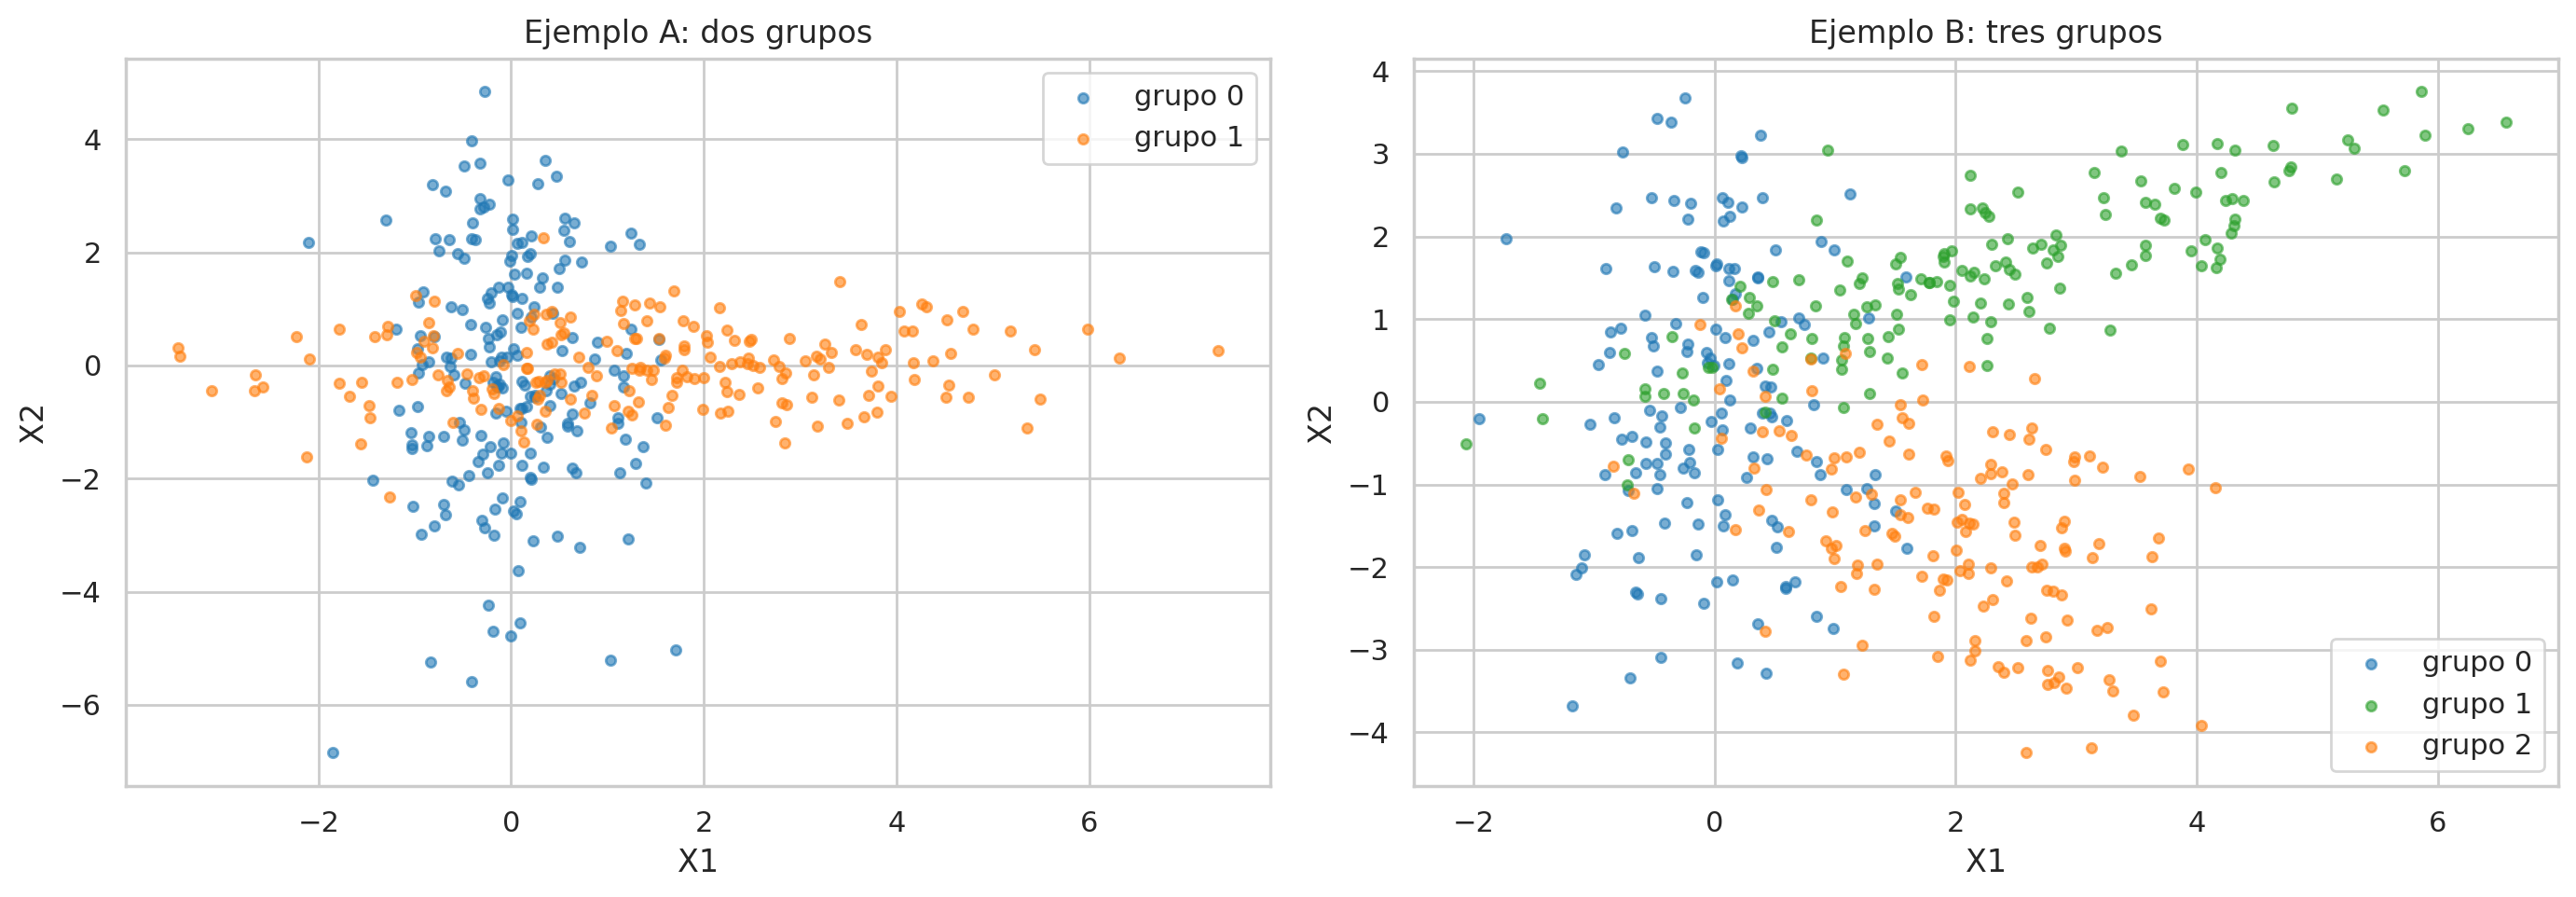

In [3]:
# --- Ejemplo de juguete A: DOS grupos (nubes con formas muy distintas y solapadas) ---
rng = np.random.RandomState(2024)
n = 200
X0 = rng.multivariate_normal([0.0, 0.0], [[0.4, 0.0], [0.0, 4.0]], n)   # nube "vertical"
X1 = rng.multivariate_normal([1.2, 0.0], [[4.0, 0.0], [0.0, 0.4]], n)   # nube "horizontal"
sim2 = pd.DataFrame(np.vstack([X0, X1]), columns=['X1', 'X2'])
sim2['target'] = pd.Series(np.r_[np.zeros(n), np.ones(n)].astype(int)).astype('category')

# --- Ejemplo de juguete B: TRES grupos (también solapados, con formas distintas) ---
medias = [[0, 0], [2.2, 1.5], [2.0, -1.5]]
covs = [[[0.5, 0], [0, 3]], [[3, 1.5], [1.5, 1]], [[1, -0.6], [-0.6, 1.2]]]
Xs, ys = [], []
for k, (mu, cov) in enumerate(zip(medias, covs)):
    Xs.append(rng.multivariate_normal(mu, cov, 150)); ys += [k] * 150
sim3 = pd.DataFrame(np.vstack(Xs), columns=['X1', 'X2'])
sim3['target'] = pd.Series(np.array(ys)).astype('category')

## Representación de los bancos de datos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for c, col in zip([0, 1], ['tab:blue', 'tab:orange']):
    d = sim2[sim2['target'] == c]
    ax[0].scatter(d['X1'], d['X2'], s=14, alpha=.6, color=col, label=f'grupo {c}')
ax[0].legend()
ax[0].set_title('Ejemplo A: dos grupos')
ax[0].set_xlabel('X1')
ax[0].set_ylabel('X2')
for c, col in zip([0, 1, 2], ['tab:blue', 'tab:green', 'tab:orange']):
    d = sim3[sim3['target'] == c]
    ax[1].scatter(d['X1'], d['X2'], s=14, alpha=.6, color=col, label=f'grupo {c}')
ax[1].legend()
ax[1].set_title('Ejemplo B: tres grupos')
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
plt.tight_layout()
plt.show()

**¿Qué queremos hacer?** Mirando los gráficos, el objetivo del análisis discriminante es **trazar las fronteras** que mejor separen estas nubes y, con ellas, asignar cualquier punto nuevo a un grupo. Fíjate en dos cosas que harán de hilo conductor: (1) las nubes **se solapan** (habrá errores inevitables) y (2) tienen **formas distintas** (unas más alargadas que otras y en direcciones diferentes). Esa diferencia de forma es precisamente lo que el LDA **no** tiene en cuenta —porque supone forma común— y lo que el QDA aprovechará después.

# <font color="steelblue">3. Análisis discriminante lineal: fundamentos</font>

En primer lugar describimos los aspectos teóricos del análisis discriminante.


## <font color="steelblue">3.1. La hipótesis gaussiana y los elipsoides</font>

El LDA supone que, **dentro de cada grupo**, las predictoras siguen una **normal multivariante** con media propia $\mu_k$ y una **matriz de covarianzas común** $\Sigma$:

$$f_k(x)=\frac{1}{(2\pi)^{q/2}|\Sigma|^{1/2}}\exp\!\left\{-\tfrac{1}{2}(x-\mu_k)^\top \Sigma^{-1}(x-\mu_k)\right\}.$$

Geométricamente, una normal bivariante "dibuja" **elipses**: el centro es la media $\mu_k$ y la orientación y el tamaño los marca la covarianza. La cantidad $(x-\mu_k)^\top \Sigma^{-1}(x-\mu_k)$ es la **distancia de Mahalanobis**, una distancia que se adapta a la forma de la elipse (cuenta menos moverse en la dirección en que la nube es ancha y más en la que es estrecha).

La hipótesis clave del LDA es que **esa elipse tiene la misma forma para todos los grupos** (solo cambia el centro). Vamos a *verlo* sobre nuestros ejemplos: dibujamos la elipse **real** de cada grupo (línea continua) y la elipse que el LDA **asume** (la covarianza común, en línea discontinua, centrada en cada grupo).

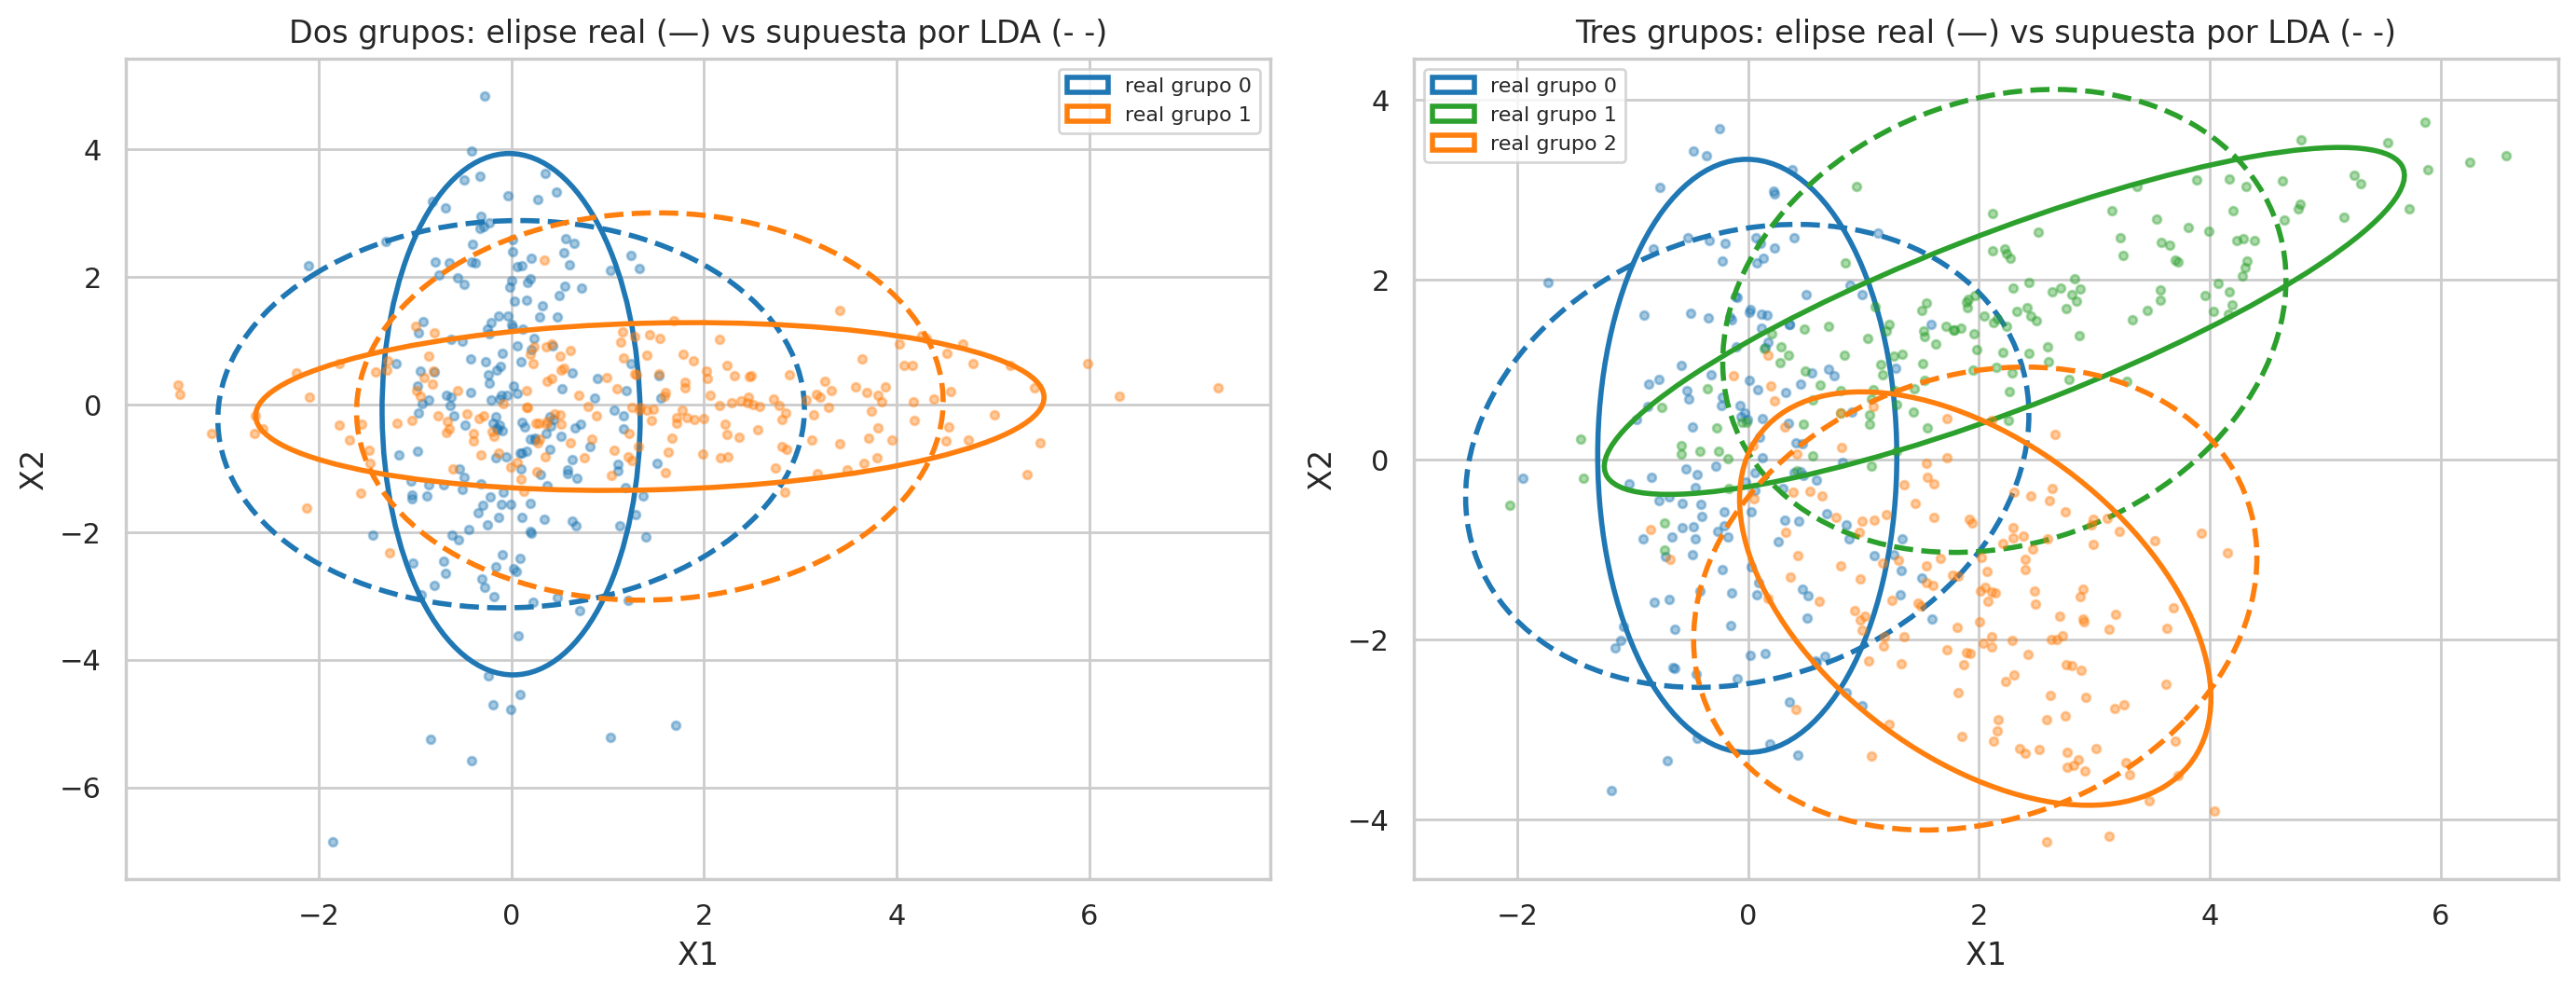

In [4]:
def dibujar_elipse(media, cov, ax, color, n_std=2.0, ls='-', lw=2, label=None):
    vals, vecs = np.linalg.eigh(cov)
    orden = vals.argsort()[::-1]; vals, vecs = vals[orden], vecs[:, orden]
    angulo = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(media, w, h, angle=angulo, edgecolor=color, fc='none', lw=lw, ls=ls, label=label))

def pooled_cov(df):
    grupos = df['target'].unique(); covs, pesos = [], []
    for g in grupos:
        d = df[df['target'] == g][['X1', 'X2']].values
        covs.append(np.cov(d.T)); pesos.append(len(d) - 1)
    return np.average(covs, axis=0, weights=pesos)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for datos, a, cols, tit in [(sim2, ax[0], ['tab:blue', 'tab:orange'], 'Dos grupos'),
                            (sim3, ax[1], ['tab:blue', 'tab:green', 'tab:orange'], 'Tres grupos')]:
    Sw = pooled_cov(datos)
    for c, col in zip(sorted(datos['target'].unique()), cols):
        d = datos[datos['target'] == c][['X1', 'X2']].values
        a.scatter(d[:, 0], d[:, 1], s=10, alpha=.4, color=col)
        dibujar_elipse(d.mean(0), np.cov(d.T), a, col, ls='-', label=f'real grupo {c}')
        dibujar_elipse(d.mean(0), Sw, a, col, ls='--')
    a.set_title(f'{tit}: elipse real (—) vs supuesta por LDA (- -)')
    a.legend(fontsize=8)
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.tight_layout()
plt.show()

**Interpretación.** Las elipses **continuas** (la forma real de cada grupo) son **distintas entre sí** —en el ejemplo de dos grupos, una es vertical y la otra horizontal—. Las elipses **discontinuas** (lo que el LDA supone) son **todas iguales**. Aquí se ve de un vistazo que **los datos violan la hipótesis de homogeneidad** del LDA: el modelo trabajará con una forma promedio que no encaja del todo con ninguna nube. Esto anticipa que la frontera lineal cometerá errores que un modelo con elipses propias (QDA) podría evitar.

## <font color="steelblue">3.2. De la hipótesis a la frontera lineal</font>

Si las covarianzas son iguales, al comparar las densidades de dos grupos los términos cuadráticos en $x$ **se cancelan** y queda una regla **lineal**. Para dos grupos:

$$w^\top x \;\gtrless\; w^\top\!\left(\tfrac{\mu_1+\mu_2}{2}\right)-\log\frac{\pi_2}{\pi_1},\qquad w=\Sigma^{-1}(\mu_2-\mu_1).$$

Es decir, se proyecta cada punto sobre la dirección $w$ y se compara con un umbral situado en el punto medio entre las dos clases (corregido por las previas). La función $g(x)=w^\top x$ es la **función discriminante**, y la frontera $g(x)=$ umbral es un **hiperplano** (una recta en 2D). **La linealidad es consecuencia directa de la covarianza compartida.**

## <font color="steelblue">3.3. Estimación de los parámetros</font>

En la práctica, $\mu_k$, $\pi_k$ y $\Sigma$ se estiman de los datos: las previas como proporciones $\hat\pi_k=n_k/n$; las medias como la media de cada grupo $\bar x_k$; y la covarianza común **agrupando** (*pooling*) las covarianzas de cada grupo, $\hat S_w=\sum_k \frac{n_k-1}{n-K}\hat S_k$ (la elipse discontinua que dibujamos antes).






## <font color="steelblue">3.4. Variables canónicas: visualizando el efecto de las funciones discriminantes</font>

Con más de dos grupos, el LDA construye **variables canónicas**: combinaciones lineales $z=w^\top x$ que **maximizan la separación entre grupos** relativa a la dispersión interna,

$$\max_{w}\ \frac{w^\top B\,w}{w^\top W\,w},$$

cuya solución son los vectores propios de $W^{-1}B$ ($B$ = dispersión entre grupos, $W$ = dispersión dentro). Se obtienen como máximo $r=\min(K-1,q)$ funciones: con **2 grupos, 1** función; con **3 grupos, 2**. Vamos a *ver* su efecto proyectando los dos ejemplos de juguete sobre sus funciones discriminantes.

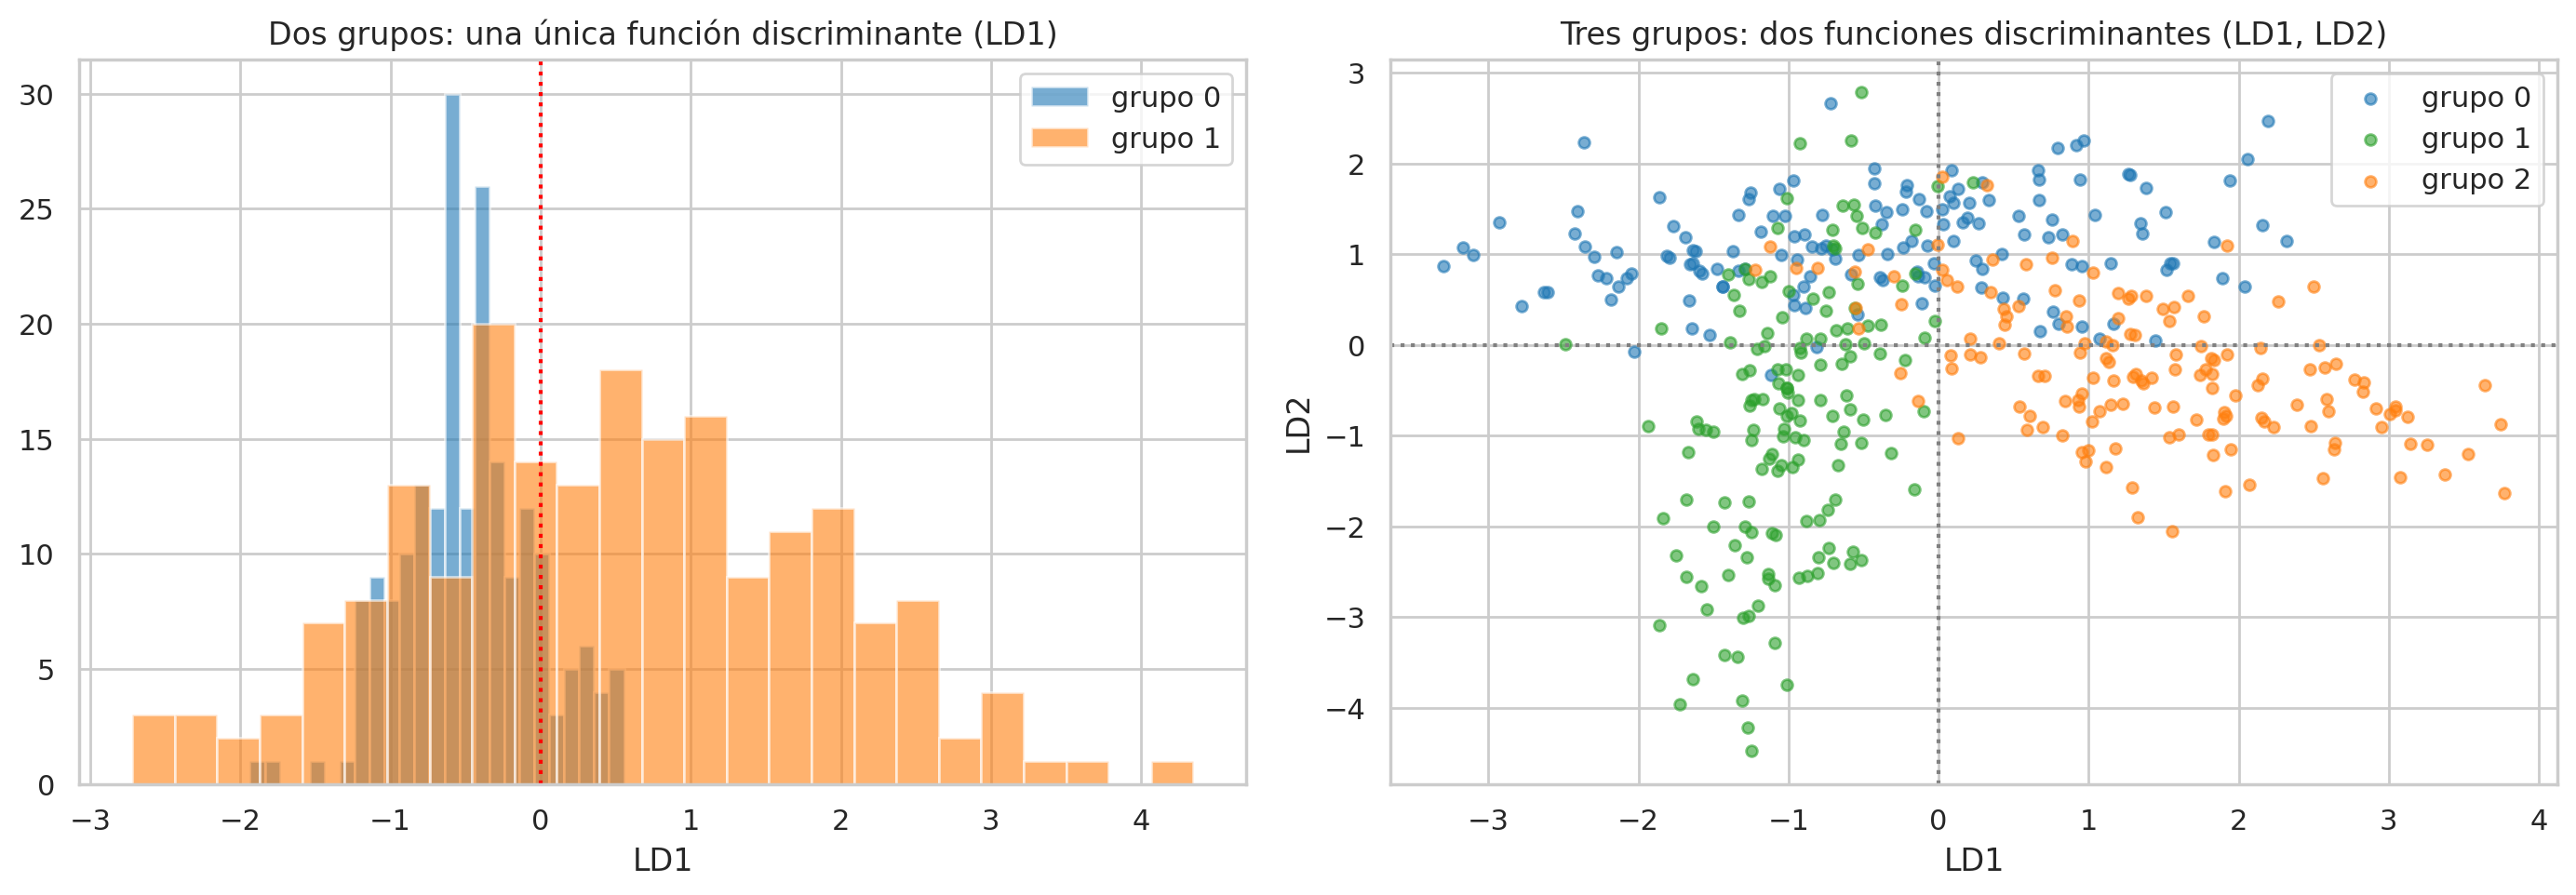

Varianza explicada (3 grupos): [0.601 0.399]


In [6]:
# Estandarizamos y ajustamos LDA a cada ejemplo (solo para ilustrar la proyección)
def proyeccion_lda(datos):
    X = StandardScaler().fit_transform(datos[['X1', 'X2']]); y = datos['target'].astype(int).values
    m = LDA().fit(X, y); return m.transform(X), y, m
# Proyectamos los puntos en el esapcio de las funciones discriminantes
z2, y2, m2 = proyeccion_lda(sim2)
z3, y3, m3 = proyeccion_lda(sim3)

# Representación gráfica de las puntuaciones de las funciones discriminantes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Dos grupos -> 1 función discriminante (histograma sobre LD1)
for c, col in zip([0, 1], ['tab:blue', 'tab:orange']):
    ax[0].hist(z2[y2 == c, 0], bins=25, alpha=.6, color=col, label=f'grupo {c}')
ax[0].axvline(0, color='red', ls=':')
ax[0].set_xlabel('LD1')
ax[0].legend()
ax[0].set_title('Dos grupos: una única función discriminante (LD1)')
# Tres grupos -> 2 funciones discriminantes (plano LD1-LD2)
for c, col in zip([0, 1, 2], ['tab:blue', 'tab:green', 'tab:orange']):
    ax[1].scatter(z3[y3 == c, 0], z3[y3 == c, 1], s=18, alpha=.6, color=col, label=f'grupo {c}')
ax[1].axhline(0, color='gray', ls=':')
ax[1].axvline(0, color='gray', ls=':')
ax[1].set_xlabel('LD1')
ax[1].set_ylabel('LD2')
ax[1].legend()
ax[1].set_title('Tres grupos: dos funciones discriminantes (LD1, LD2)')
plt.tight_layout()
plt.show()
print('Varianza explicada (3 grupos):', np.round(m3.explained_variance_ratio_, 3))

A la izquierda (problema con dos grupos) solo hay **una** función discriminante: los puntos se reducen a un eje (LD1) y la clasificación es "a la izquierda o a la derecha del umbral". El solapamiento de los histogramas en torno a 0 son los errores inevitables. A la derecha (tres grupos) hay **dos** funciones: **LD1** (la de mayor varianza explicada) hace el grueso de la separación y **LD2** ayuda a distinguir lo que LD1 no logra. Este es el sentido de "reducir la dimensión maximizando la separación": pasamos de las variables originales a 1 o 2 ejes que **muestran** la estructura de clases.

## <font color="steelblue">3.5. Probabilidades, hipótesis y precisión</font>

Además de clasificar, el LDA entrega **probabilidades** (`predict_proba`): el logaritmo de la posterior es lineal en $x$, con pesos `coef_` ($\beta_k=\Sigma^{-1}\mu_k$) e `intercept_`. Para que el LDA sea **óptimo** se deben cumplir dos **hipótesis**: normalidad multivariante por grupo y homogeneidad de covarianzas; las contrastaremos con `pingouin` (`multivariate_normality`, test de Henze–Zirkler, y `box_m`, test M de Box). Y la **precisión** se mide con las herramientas de siempre: **matriz de confusión**, **validación cruzada** y **curva de aprendizaje**.

# <font color="steelblue">4. LDA en scikit-learn</font>

La clase es **`sklearn.discriminant_analysis.LinearDiscriminantAnalysis`**. Como recordatorio de su doble naturaleza, LDA es a la vez un **clasificador** (`predict`/`predict_proba`) y un **reductor de dimensión supervisado** (`transform`, a lo sumo $\min(K-1,\,p)$ ejes, con $K$ clases y $p$ variables). Los hiperparámetros `solver` y `shrinkage` se optimizan en la sección 6.

## <font color="steelblue">4.1. Parámetros del constructor</font>

* **`solver`** `{'svd', 'lsqr', 'eigen'}`, def. `'svd'` — algoritmo de ajuste:
  * **`'svd'`** (descomposición en valores singulares): **no calcula la matriz de covarianza**, por lo que es el recomendado con **muchas variables**; **no admite `shrinkage`** ni `covariance_estimator`.
  * **`'lsqr'`** (mínimos cuadrados): eficiente, **admite `shrinkage`**; solo clasifica (no aporta los ejes para `transform`).
  * **`'eigen'`** (descomposición en autovalores): **admite `shrinkage`** y da el análisis canónico completo (`explained_variance_ratio_`); más costoso con muchas variables.
* **`shrinkage`** `None | 'auto' | float ∈ [0, 1]`, def. `None` — **contracción** de la covarianza hacia una diagonal, que **estabiliza** la estimación con **pocas muestras o muchas variables**. `'auto'` la calcula con el lema de **Ledoit-Wolf**; un `float` la fija a mano (0 = sin contracción, 1 = covarianza diagonal). **Solo con `lsqr`/`eigen`** (no con `svd`).
* **`priors`** `array (n_classes,)`, def. `None` — **probabilidades a priori** de cada clase. Por defecto se estiman de las frecuencias del entrenamiento; **igualarlas** (p. ej. `1/K` para todas) **compensa el desbalanceo**, ya que LDA **no** tiene `class_weight`.
* **`n_components`** `int`, def. `None` — número de **funciones discriminantes canónicas** que devuelve `transform` (reducción de dimensión). Si es `None`, vale $\min(K-1,\,p)$. **Solo afecta a `transform`**, no a la clasificación.
* **`store_covariance`** `bool`, def. `False` — si `True`, calcula y guarda la **covarianza intra-clase ponderada** también con `solver='svd'` (con `lsqr`/`eigen` se guarda siempre).
* **`tol`** `float`, def. `1e-4` — umbral para considerar **significativo** un valor singular de `X` (sirve para estimar su rango y descartar direcciones degeneradas). **Solo con `svd`**.
* **`covariance_estimator`** estimador, def. `None` — permite usar un **estimador de covarianza a medida** (Ledoit-Wolf, OAS…) en lugar del empírico. Solo con `lsqr`/`eigen` y es **incompatible con `shrinkage`** (se usa uno u otro).

## <font color="steelblue">4.2. Atributos tras ajustar</font>

* **`coef_`** — **coeficientes** de la frontera lineal: forma `(n_clases, n_features)` (en binario, `(1, n_features)`).
* **`intercept_`** — términos independientes, uno por clase.
* **`means_`** `(n_clases, n_features)` — **centroides** (media de cada clase); el corazón geométrico de LDA.
* **`priors_`** `(n_clases,)` — probabilidades a priori **efectivamente usadas** (las de `priors` o las estimadas).
* **`scalings_`** — **coeficientes canónicos**: las direcciones que definen los ejes a los que proyecta `transform` (máxima separación entre clases).
* **`explained_variance_ratio_`** `(n_components,)` — proporción de **varianza entre clases** que captura cada eje canónico (con `svd`/`eigen`); útil para decidir cuántos ejes retener.
* **`covariance_`** `(n_features, n_features)` — covarianza intra-clase ponderada (disponible si `store_covariance=True` o con `lsqr`/`eigen`).
* **`xbar_`** `(n_features,)` — **media global** de los datos (con `svd`).
* **`classes_`** — etiquetas de clase ordenadas (definen el orden de filas/columnas de los demás atributos y de `predict_proba`).
* **`n_features_in_`** / **`feature_names_in_`** — nº y nombres de las variables vistas en `fit` (los nombres, si `X` era un `DataFrame`).

## <font color="steelblue">4.3. Métodos principales</font>

* **`fit(X, y)`** — ajusta el modelo (estima centroides, covarianza y ejes canónicos).
* **`predict(X)`** — **clase** predicha.
* **`predict_proba(X)`** / **`predict_log_proba(X)`** — **probabilidades** posteriores por clase (y su logaritmo).
* **`decision_function(X)`** — **puntuación lineal** por clase (distancia con signo a la frontera); en binario, el signo da la clase.
* **`transform(X)`** — proyecta `X` sobre las `n_components` **funciones discriminantes** (reducción de dimensión supervisada, para visualizar o preprocesar).
* **`fit_transform(X, y)`** — `fit` + `transform` en un paso.
* **`score(X, y)`** — **exactitud** (*accuracy*) media.
* **`get_params()` / `set_params(**kwargs)`** — leer/fijar hiperparámetros (los usan `Pipeline` y `GridSearchCV`).
* **`get_feature_names_out()` / `set_output(transform='pandas')`** — nombres de las salidas de `transform` y opción para que devuelva un `DataFrame`.

# <font color="steelblue">5. Aplicaciones</font>

Retomamos los dos ejemplos simulados (ahora con un flujo completo de entrenamiento/validación) y añadimos dos casos **reales**: *water potability* (2 grupos) y *abalone* (3 grupos).

## <font color="steelblue">5.1. Ejemplo simulado con dos grupos</font>

Usamos el conjunto `sim2` creado en la sección 2. Comprobamos primero las **hipótesis** del LDA (lo que ya intuíamos con los elipsoides).

In [7]:
g0 = sim2[sim2['target'] == 0]; g1 = sim2[sim2['target'] == 1]
print('Normalidad grupo 0:', pingouin.multivariate_normality(g0[['X1','X2']], alpha=.05))
print('Normalidad grupo 1:', pingouin.multivariate_normality(g1[['X1','X2']], alpha=.05))
print('\nHomogeneidad de covarianzas (M de Box):')
print(pingouin.box_m(sim2, dvs=['X1','X2'], group='target'))

Normalidad grupo 0: HZResults(hz=np.float64(0.6596768856397539), pval=np.float64(0.4043785851430593), normal=True)
Normalidad grupo 1: HZResults(hz=np.float64(0.4191445879467848), pval=np.float64(0.8772250915371607), normal=True)

Homogeneidad de covarianzas (M de Box):
           Chi2   df          pval  equal_cov
box  423.433271  3.0  1.857753e-91      False


Cada grupo es normal, pero el test M de Box **rechaza** la homogeneidad: confirma numéricamente lo que veíamos en los elipsoides. Aun así aplicamos el LDA como modelo basal. Dividimos y preprocesamos antes de proceder con el entrenamiento.

In [8]:
strain_raw, stest_raw = split_sample(sim2, 'target', 0.3, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'target')
stest,  _    = preprocesar_datos(stest_raw,  'target', prep)
xtrain, ytrain = strain.drop('target', axis=1), strain['target']
xtest,  ytest  = stest.drop('target', axis=1),  stest['target']
modelo = LDA().fit(xtrain, ytrain)
print('Coeficientes de la función discriminante (scalings_):')
print(pd.DataFrame(modelo.scalings_, index=['X1','X2'], columns=['LD1']).round(3))

Estratificando por 'target'.
  Entrenamiento: 280 muestras | Test: 120 muestras
Coeficientes de la función discriminante (scalings_):
      LD1
X1  1.108
X2  0.093


Visualizamos las **regiones de decisión** (rectas, por ser LDA) sobre la muestra de test.

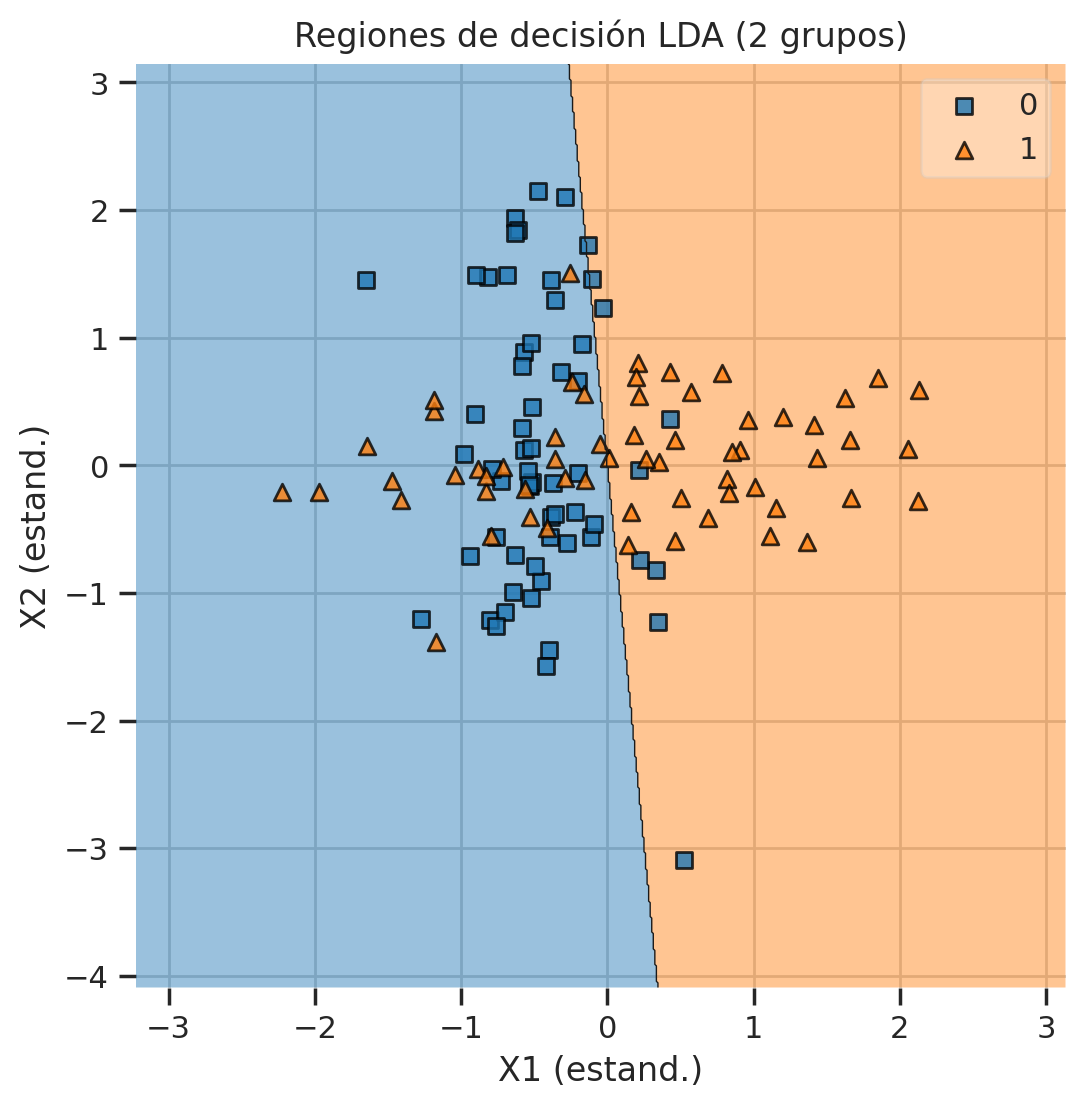

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_decision_regions(X=xtest.values, y=ytest.astype(int).values, clf=modelo, ax=ax)
ax.set_title('Regiones de decisión LDA (2 grupos)')
ax.set_xlabel('X1 (estand.)')
ax.set_ylabel('X2 (estand.)')
plt.show()

La frontera es una **recta** que, al cruzarse las nubes, deja puntos mal clasificados a ambos lados. Evaluamos el modelo entrenado con las funciones definidas.

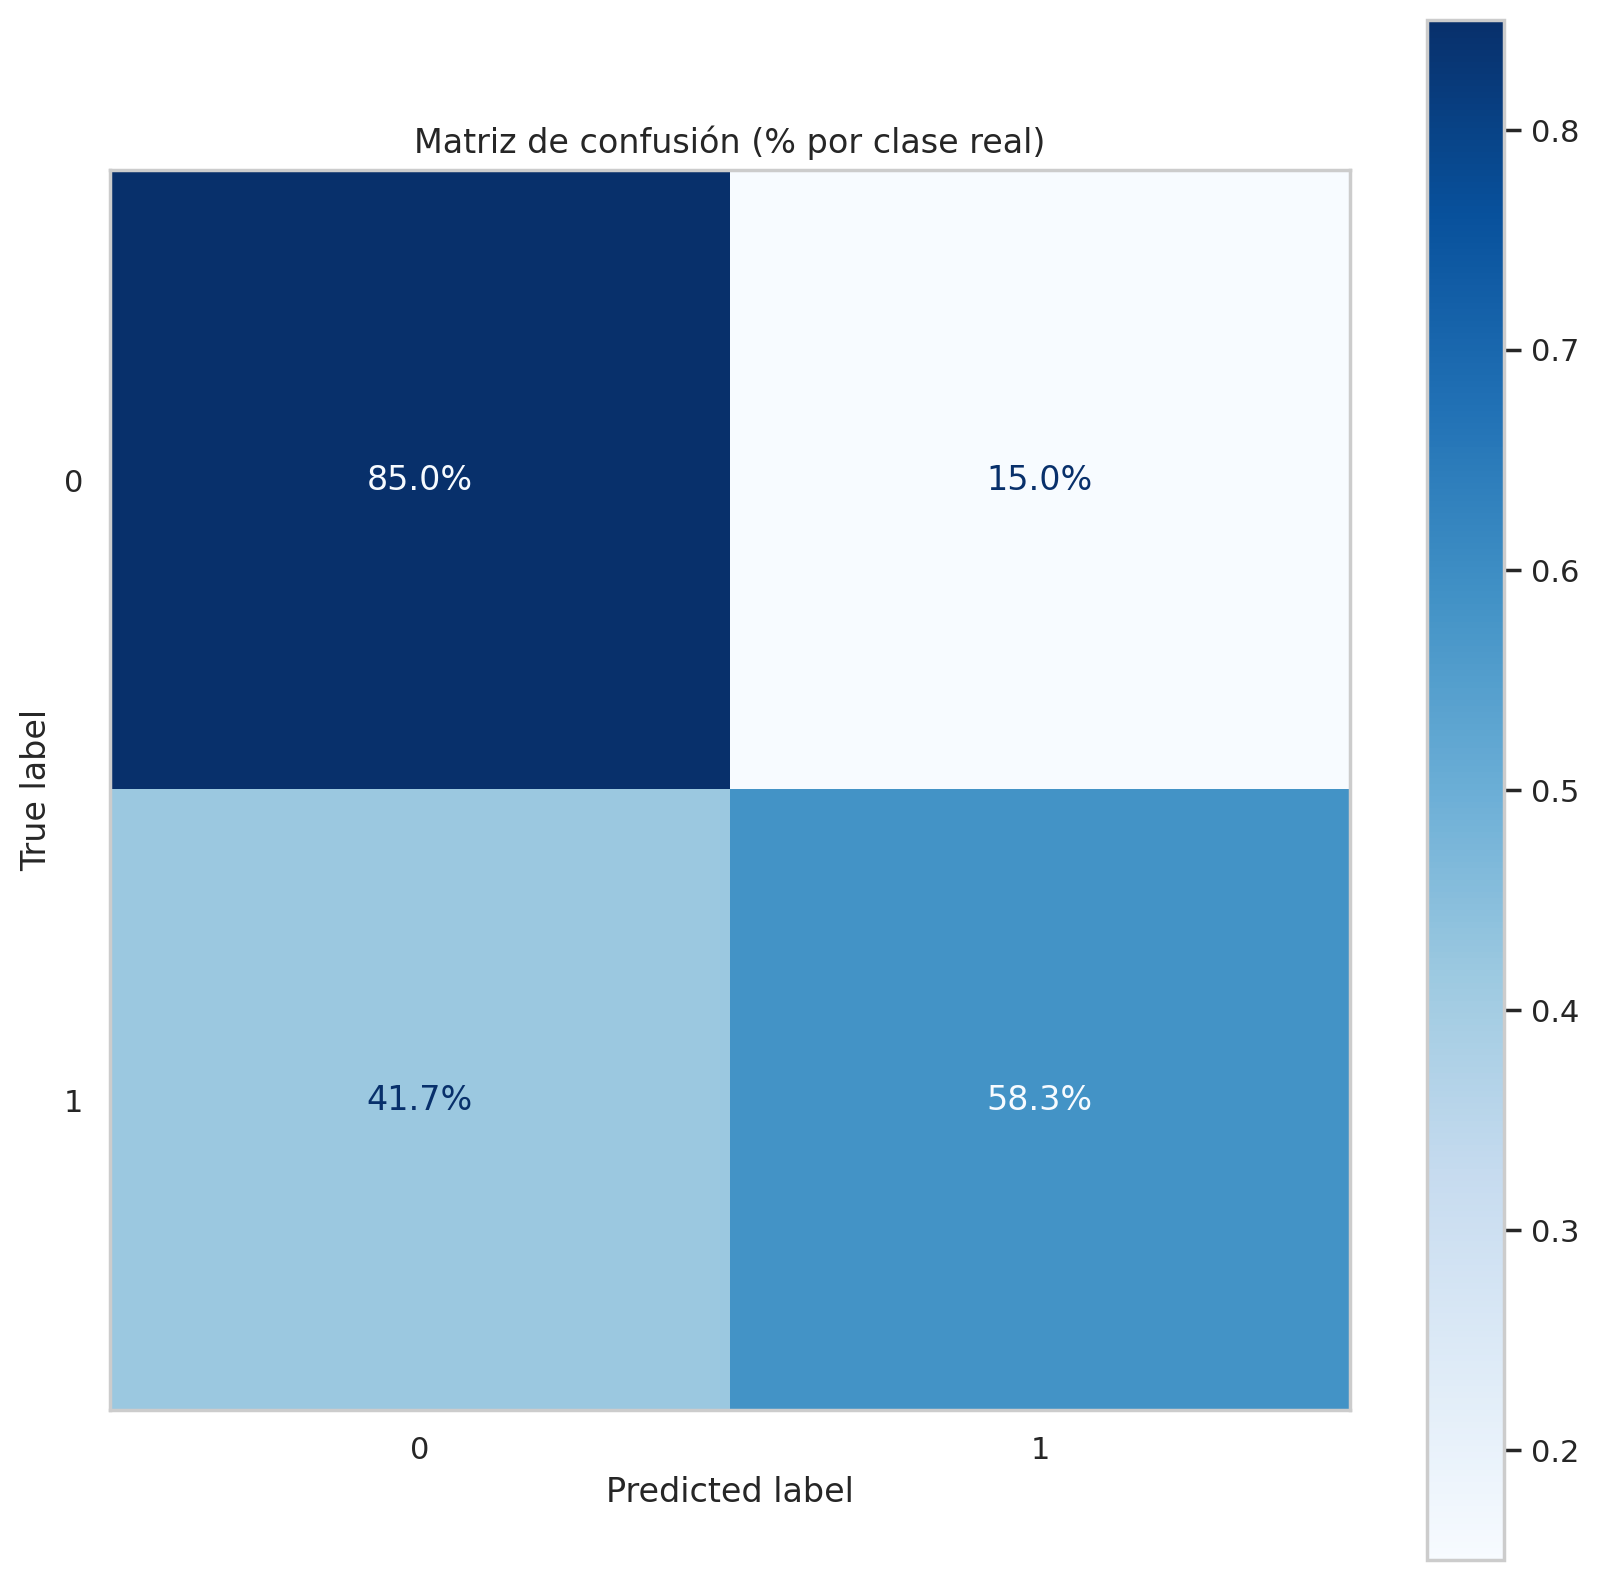

In [12]:
matriz_confusion(modelo, xtest, ytest);

In [13]:
val = validar_modelo(modelo, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.746 +/- 0.111


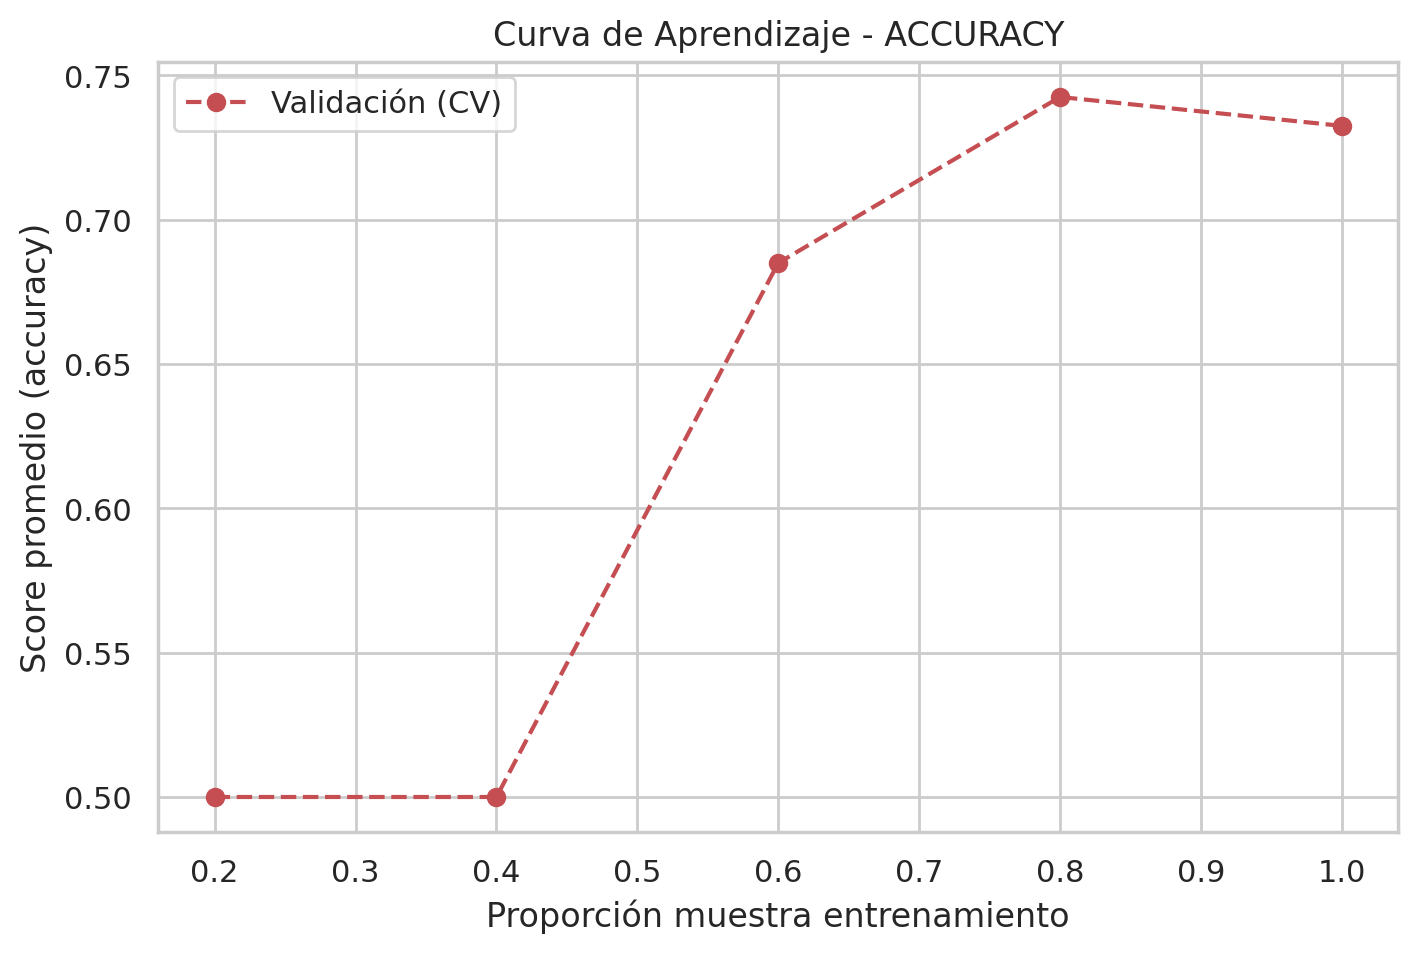

In [14]:
datos_pp, _ = preprocesar_datos(sim2, 'target')
X = datos_pp.drop('target', axis=1)
y = datos_pp['target']
curva_aprendizaje(modelo, X, y, 'accuracy', 10);

Errores repartidos en ambas clases y exactitud estable en torno a **0.73**: el modelo lineal no captura la frontera curva. La curva de aprendizaje indica que el límite es el **sesgo** del modelo lineal, no la falta de datos. Caso ideal para el QDA.


## <font color="steelblue">5.2. Ejemplo simulado con tres grupos</font>

Usamos `sim3`. Hipótesis, división y ajuste.

In [15]:
for k in [0,1,2]:
    gk = sim3[sim3['target'] == k]; print(f'Normalidad grupo {k}:', pingouin.multivariate_normality(gk[['X1','X2']], alpha=.05))
print('\nM de Box:'); print(pingouin.box_m(sim3, dvs=['X1','X2'], group='target'))

Normalidad grupo 0: HZResults(hz=np.float64(0.8052023203503594), pval=np.float64(0.16709361943247364), normal=True)
Normalidad grupo 1: HZResults(hz=np.float64(0.36701215731527737), pval=np.float64(0.9178288219316799), normal=True)
Normalidad grupo 2: HZResults(hz=np.float64(0.602728005658125), pval=np.float64(0.4613178157824719), normal=True)

M de Box:
           Chi2   df          pval  equal_cov
box  386.645361  6.0  2.075177e-80      False


In [16]:
strain_raw, stest_raw = split_sample(sim3, 'target', 0.3, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'target')
stest,  _    = preprocesar_datos(stest_raw,  'target', prep)
xtrain, ytrain = strain.drop('target', axis=1), strain['target']
xtest,  ytest  = stest.drop('target', axis=1),  stest['target']
modelo3 = LDA().fit(xtrain, ytrain)
print('Varianza explicada:', np.round(modelo3.explained_variance_ratio_, 3))

Estratificando por 'target'.
  Entrenamiento: 315 muestras | Test: 135 muestras
Varianza explicada: [0.596 0.404]


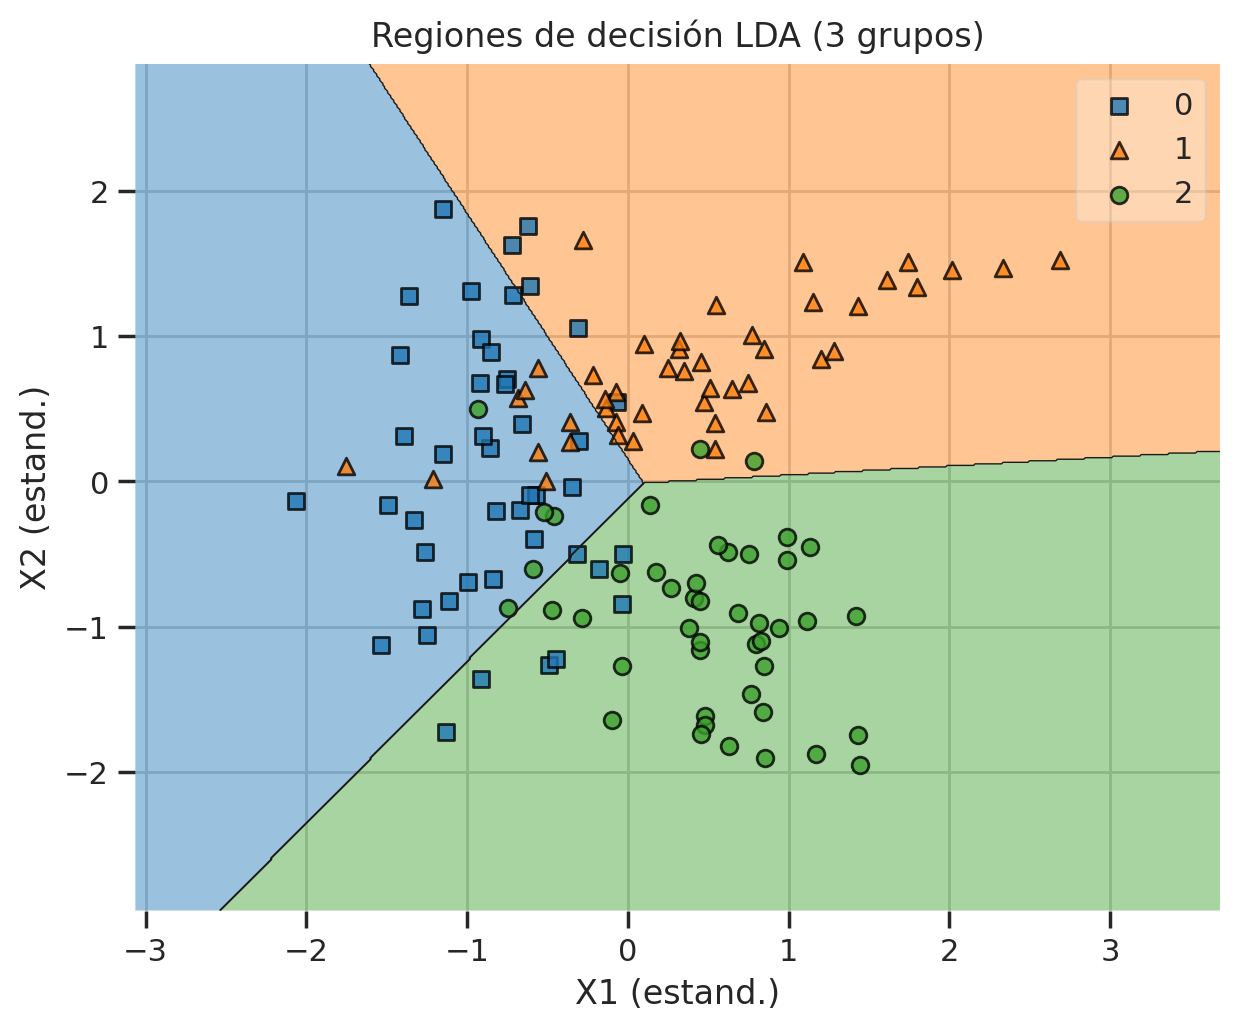

In [17]:
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_decision_regions(X=xtest.values, y=ytest.astype(int).values, clf=modelo3, ax=ax)
ax.set_title('Regiones de decisión LDA (3 grupos)')
ax.set_xlabel('X1 (estand.)')
ax.set_ylabel('X2 (estand.)')
plt.show()

El plano queda partido por **rectas** en tres regiones. Podemos ver como el modelo entrenado separa los grupos, aunque se aprecían errores de clasificación entre los grupos.

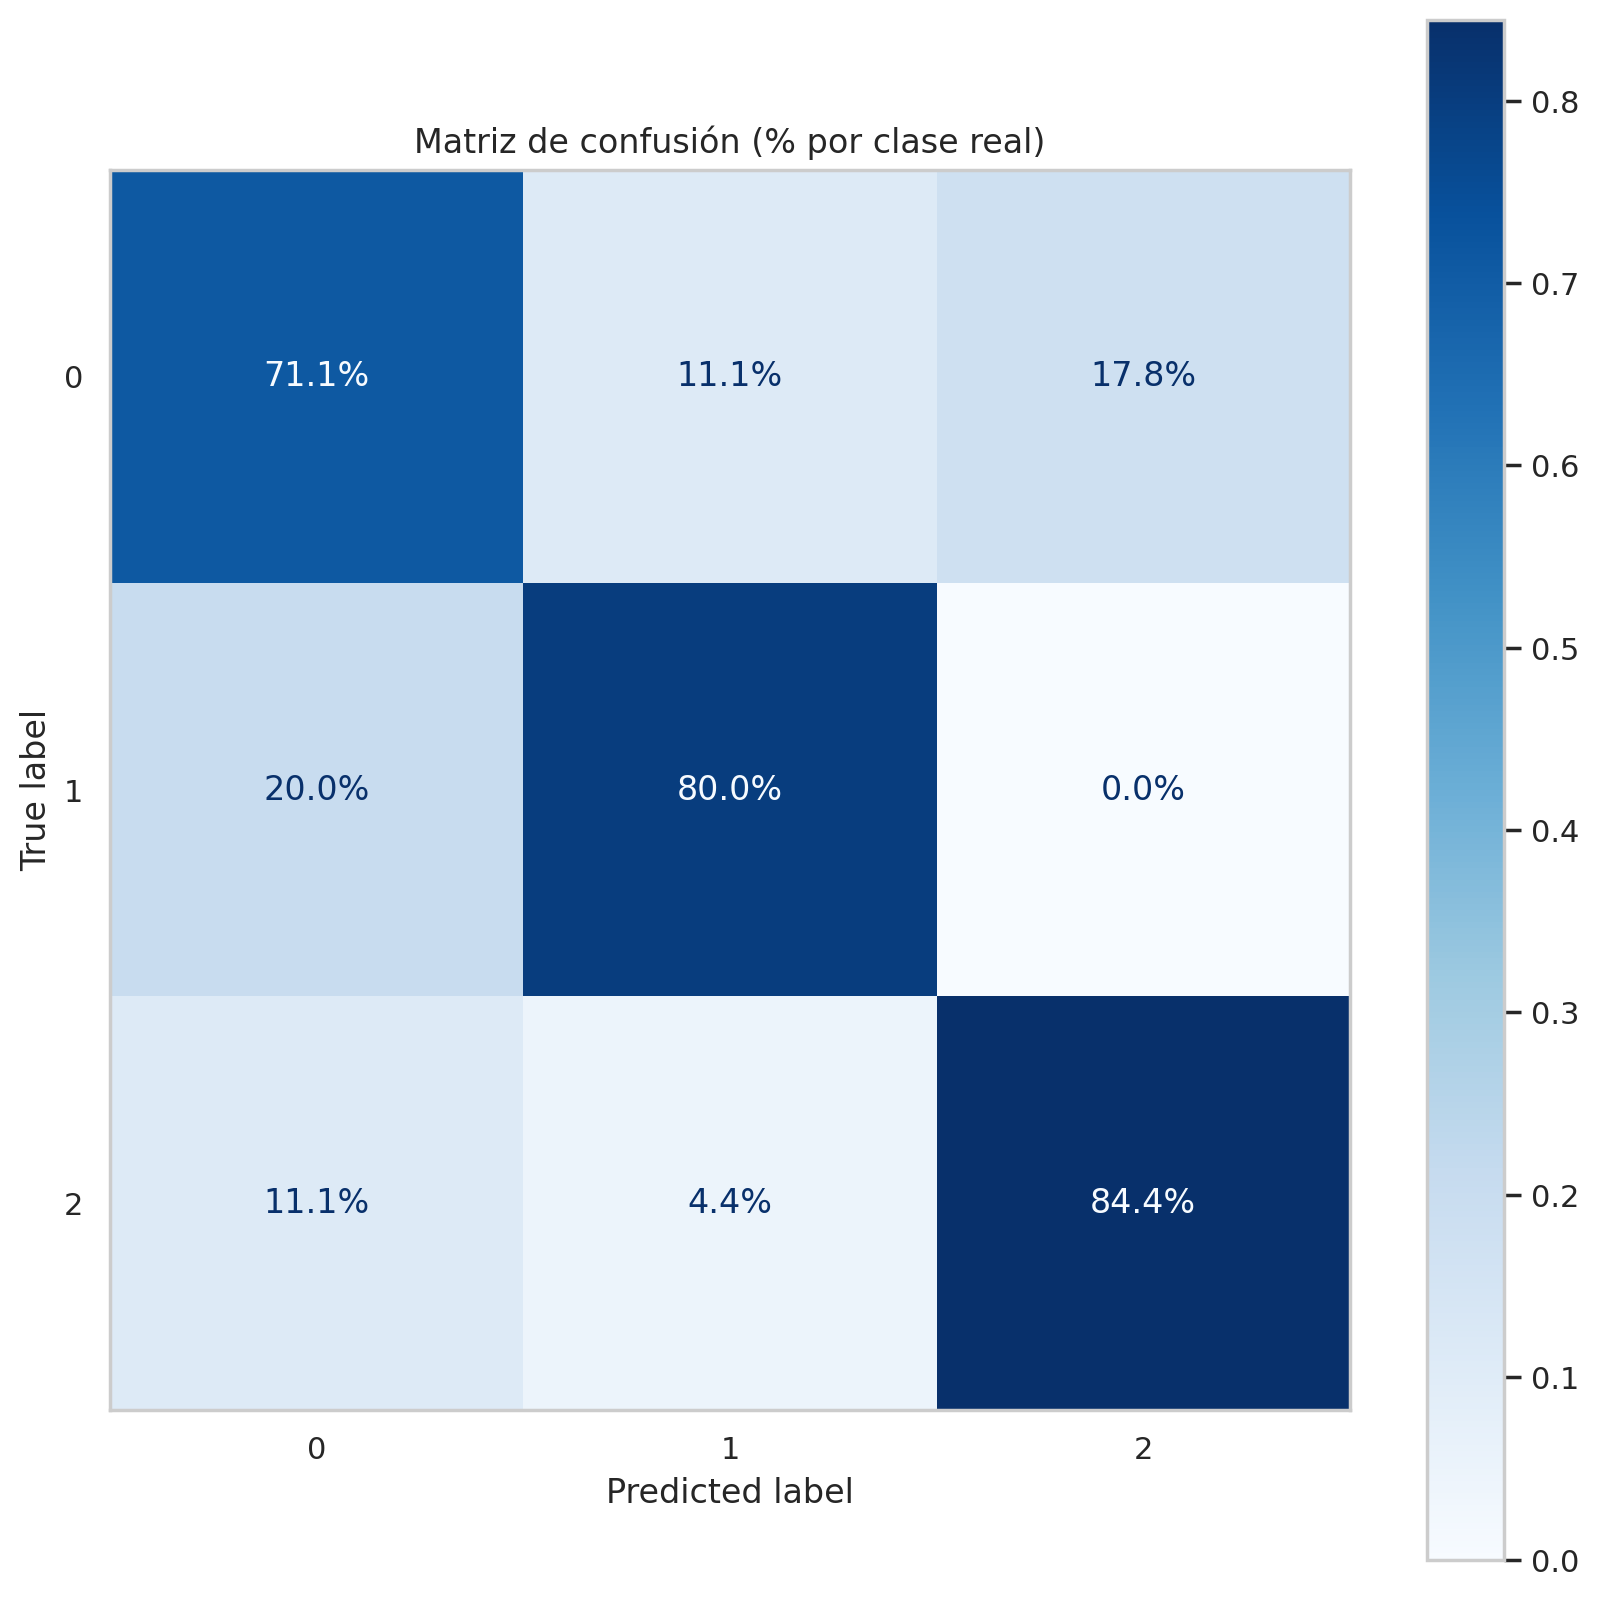

In [18]:
matriz_confusion(modelo3, xtest, ytest);

In [19]:
val3 = validar_modelo(modelo3, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.778 +/- 0.052


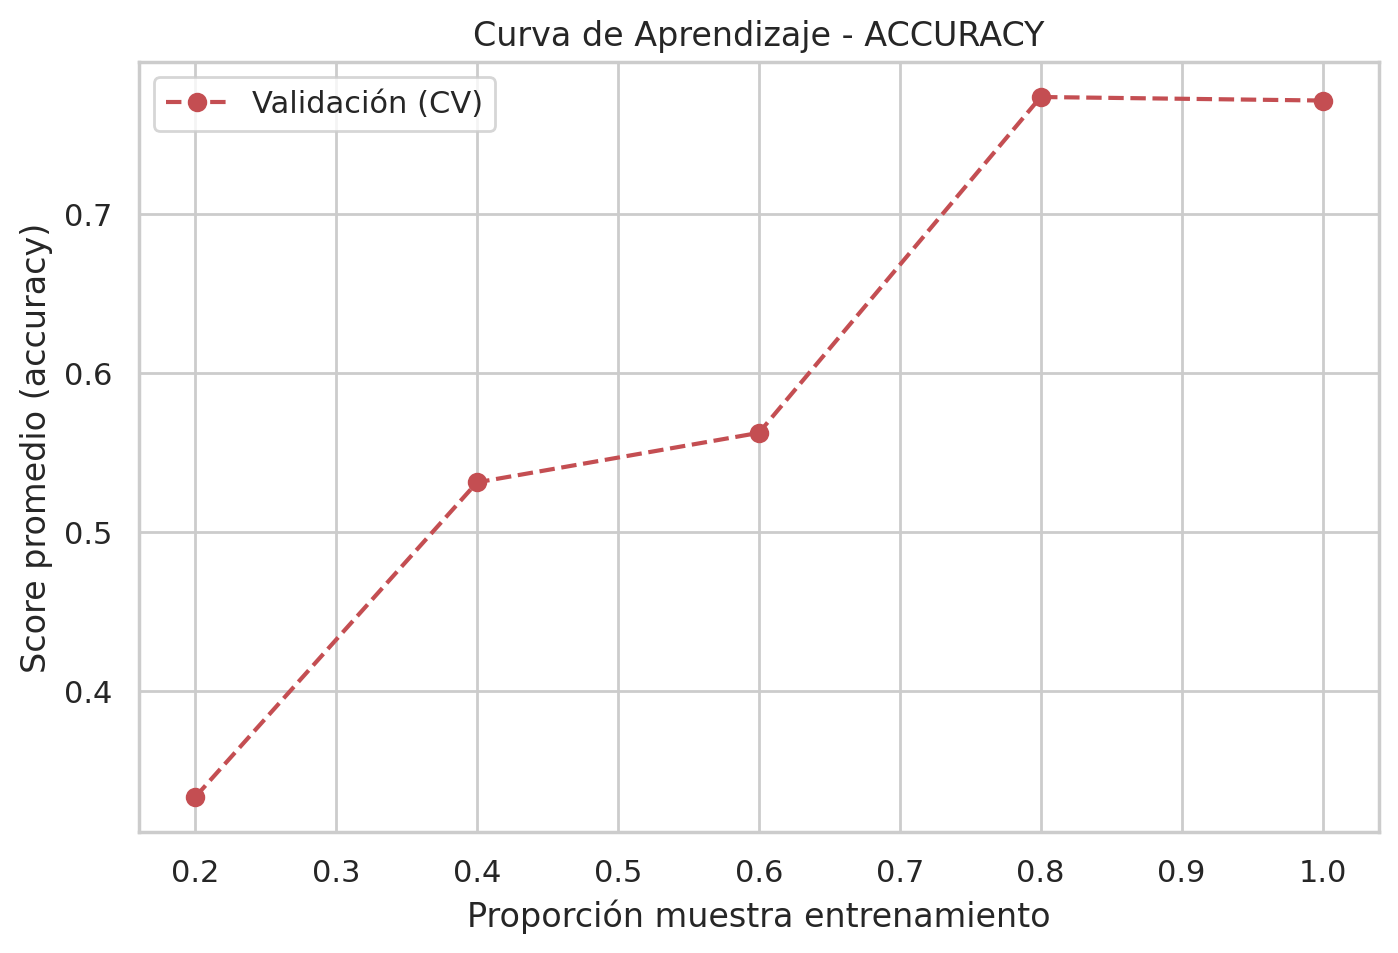

In [20]:
datos_pp, _ = preprocesar_datos(sim3, 'target')
X = datos_pp.drop('target', axis=1)
y = datos_pp['target']
curva_aprendizaje(modelo3, X, y, 'accuracy', 10);

Los errores se concentran entre las dos clases que se solapan; exactitud estable en torno a **0.81**. De nuevo, la frontera lineal limita el resultado.

## <font color="steelblue">5.3. Aplicación real: potabilidad del agua (2 grupos)</font>

**El banco de datos.** *Water potability* recoge **3.276 muestras de agua** caracterizadas por **9 variables fisicoquímicas**, con el objetivo de decidir si el agua es **potable (0)** o **no potable (1)**. Las variables son:

* **`ph`**: acidez/alcalinidad (escala 0–14).
* **`Hardness`**: dureza, asociada a sales de calcio y magnesio.
* **`Solids`**: sólidos totales disueltos (TDS), mineralización del agua.
* **`Chloramines`**: cloraminas, desinfectante habitual.
* **`Sulfate`**: sulfatos disueltos.
* **`Conductivity`**: conductividad eléctrica (depende de los iones disueltos).
* **`Organic_carbon`**: carbono orgánico total.
* **`Trihalomethanes`**: subproductos de la cloración.
* **`Turbidity`**: turbidez (materia en suspensión).

La dificultad del problema es que la potabilidad depende de **combinaciones** de estos valores y los rangos de agua potable y no potable **se solapan mucho**, por lo que cualquier modelo basado solo en estas variables tiene un techo de acierto modesto. Lo cargamos ya preprocesado.

Dimensiones: (3276, 10)


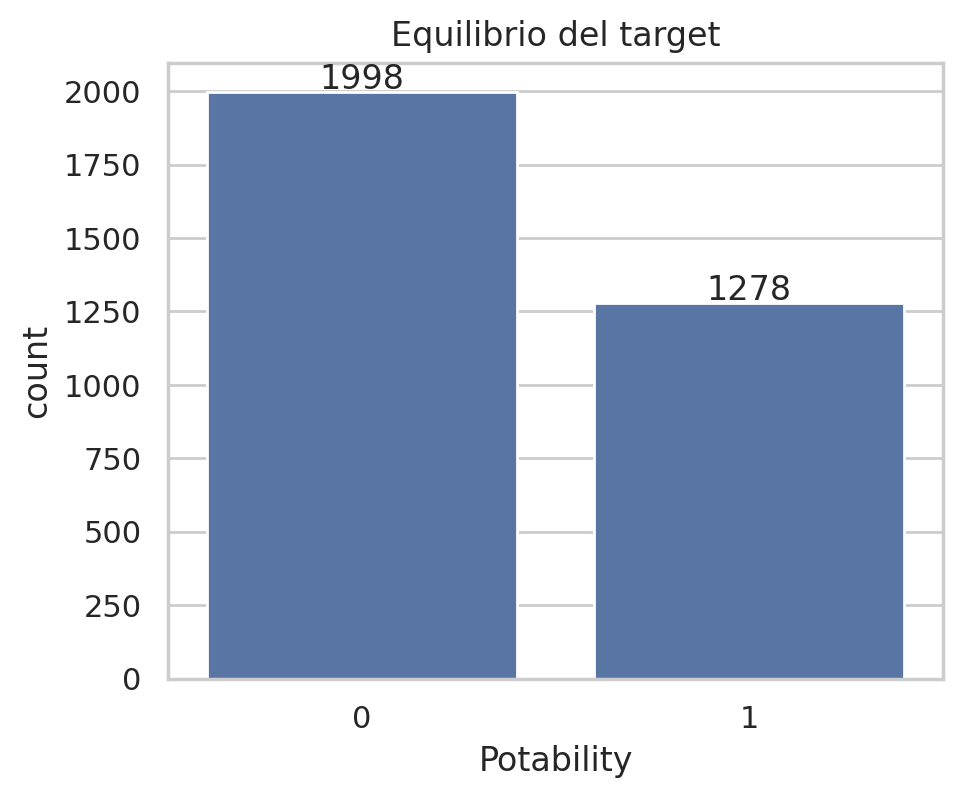

Proporciones: {0: 0.61, 1: 0.39}


In [21]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_clean.csv'
water = pd.read_csv(url, index_col=0)
water['Potability'] = water['Potability'].astype('category')
print('Dimensiones:', water.shape)
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='Potability', data=water, ax=ax)
for i, v in enumerate(water['Potability'].value_counts().sort_index().values): ax.text(i, v+10, str(v), ha='center')
ax.set_title('Equilibrio del target'); plt.show()
print('Proporciones:', water['Potability'].value_counts(normalize=True).round(3).to_dict())

Hay **desbalanceo**: ~61 % no potable (0) y ~39 % potable (1). Comprobamos hipótesis y preparamos los datos.

In [22]:
varpred = [c for c in water.columns if c != 'Potability']
for k in [0,1]:
    gk = water[water['Potability'] == k]; print(f'Normalidad grupo {k}:', pingouin.multivariate_normality(gk[varpred], alpha=.05))
print('\nM de Box:'); print(pingouin.box_m(water, dvs=varpred, group='Potability'))

Normalidad grupo 0: HZResults(hz=np.float64(1.1903995399493648), pval=np.float64(5.5434164233285744e-95), normal=False)
Normalidad grupo 1: HZResults(hz=np.float64(1.206494214867462), pval=np.float64(1.1306803559545833e-87), normal=False)

M de Box:
           Chi2    df           pval  equal_cov
box  647.161188  45.0  1.224692e-107      False


No se cumplen las hipótesis (ni normalidad ni homogeneidad), como es habitual en datos reales. Ajustamos el LDA como basal. Dividimos, entrenamos y evalaumos el modelo resultante.

In [23]:
strain_raw, stest_raw = split_sample(water, 'Potability', 0.2, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'Potability')
stest,  _    = preprocesar_datos(stest_raw,  'Potability', prep)
xtrain, ytrain = strain.drop('Potability', axis=1), strain['Potability']
xtest,  ytest  = stest.drop('Potability', axis=1),  stest['Potability']
modelo = LDA().fit(xtrain, ytrain)
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Estratificando por 'Potability'.
  Entrenamiento: 2620 muestras | Test: 656 muestras
Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.61      1.00      0.76      1598
           1       0.86      0.01      0.01      1022

    accuracy                           0.61      2620
   macro avg       0.73      0.50      0.39      2620
weighted avg       0.71      0.61      0.47      2620


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       1.00      0.01      0.02       256

    accuracy                           0.61       656
   macro avg       0.81      0.51      0.39       656
weighted avg       0.76      0.61      0.47       656



Las métricas muestran que la clasificación dentro de la categoría de agua no potable es basatnte mala. El modleo no es capaza clasificar de foma correxta las muestras originales de agua no potable.

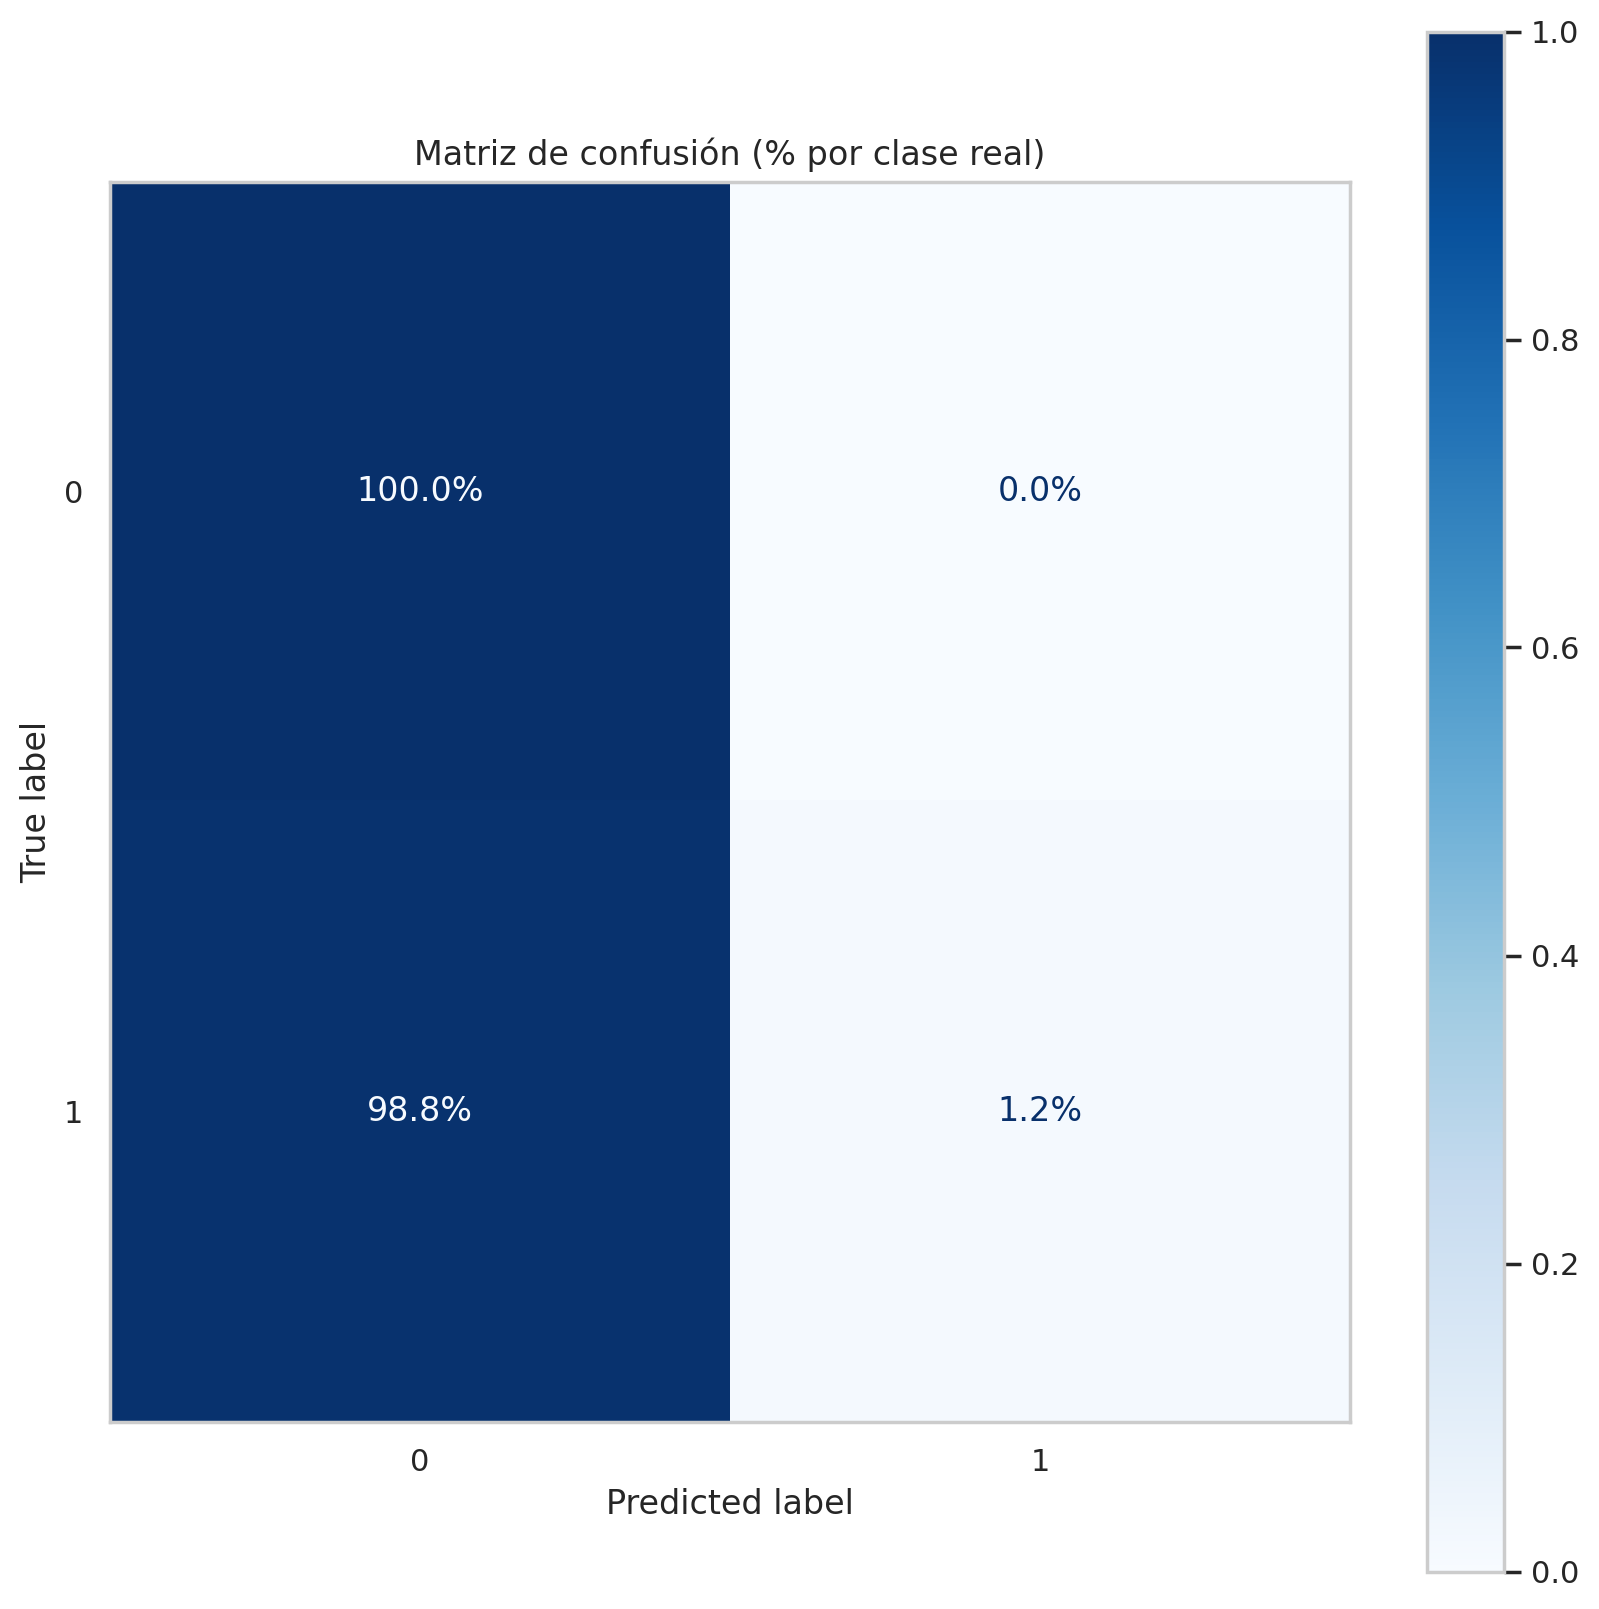

In [24]:
matriz_confusion(modelo, xtest, ytest);

El modelo clasifica bien la clase mayoritaria (agua potable) pero **apenas detecta la clase potable**: el desbalanceo unido al escaso poder discriminante hace que "tire" hacia la clase frecuente. Lo confirmamos con la curva ROC.

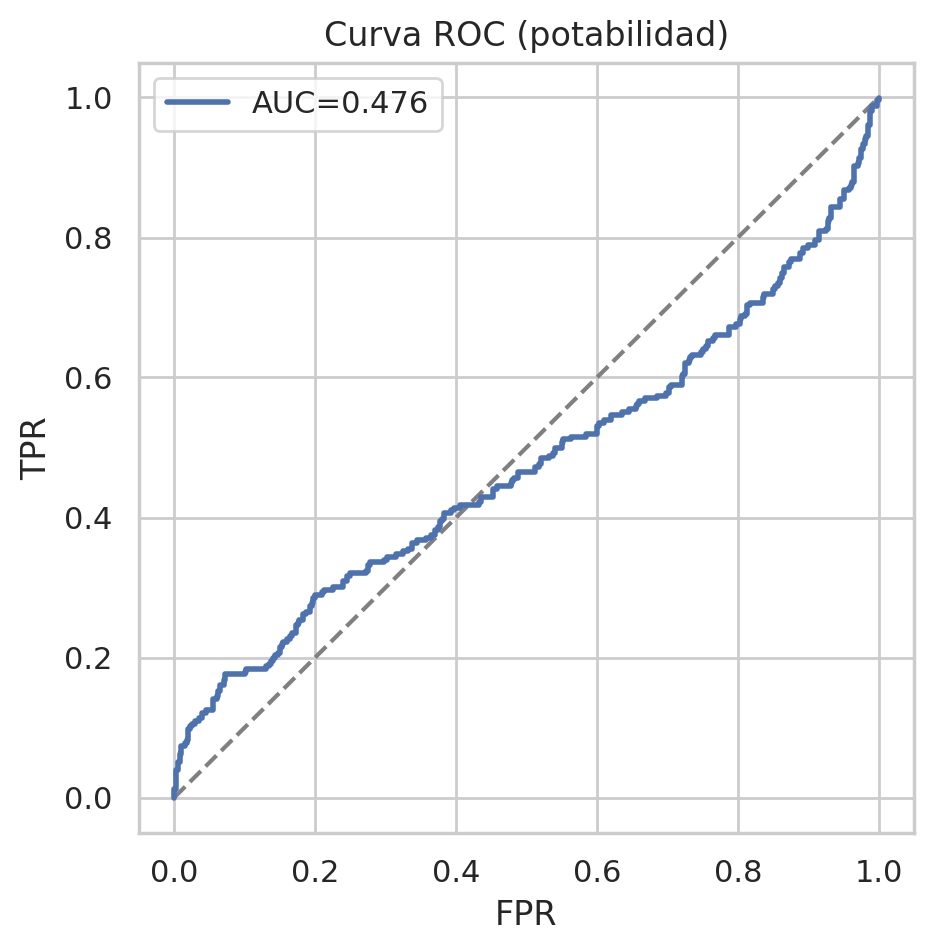

In [25]:
y_probs = modelo.predict_proba(xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest.astype(int), y_probs)
auc = roc_auc_score(ytest.astype(int), y_probs)
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],'--',color='gray')
plt.plot(fpr,tpr,lw=2,label=f'AUC={auc:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (potabilidad)')
plt.legend()
plt.show()

Verificamos la validación del modelo entrenado

In [26]:
val = validar_modelo(modelo, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.613 +/- 0.004


AUC ≈ 0.5 (curva casi sobre la diagonal): poco poder de discriminación, coherente con el incumplimiento de hipótesis.

### <font color="steelblue">5.3.1. Selección de variables y regiones de decisión</font>

Aplicamos la **selección de variables** del curso (`select_variables`, basada en RFE dentro de validación cruzada) para ver con cuántas predictoras se mantiene el rendimiento, y después dibujamos las **regiones de decisión** usando las **2 variables más relevantes** (para poder representarlas en 2D).

Calculando el ranking global de variables (puede tardar un momento)...
Evaluando combinaciones optimizando por: F1...

k óptimo: 9  |  f1: 0.4694


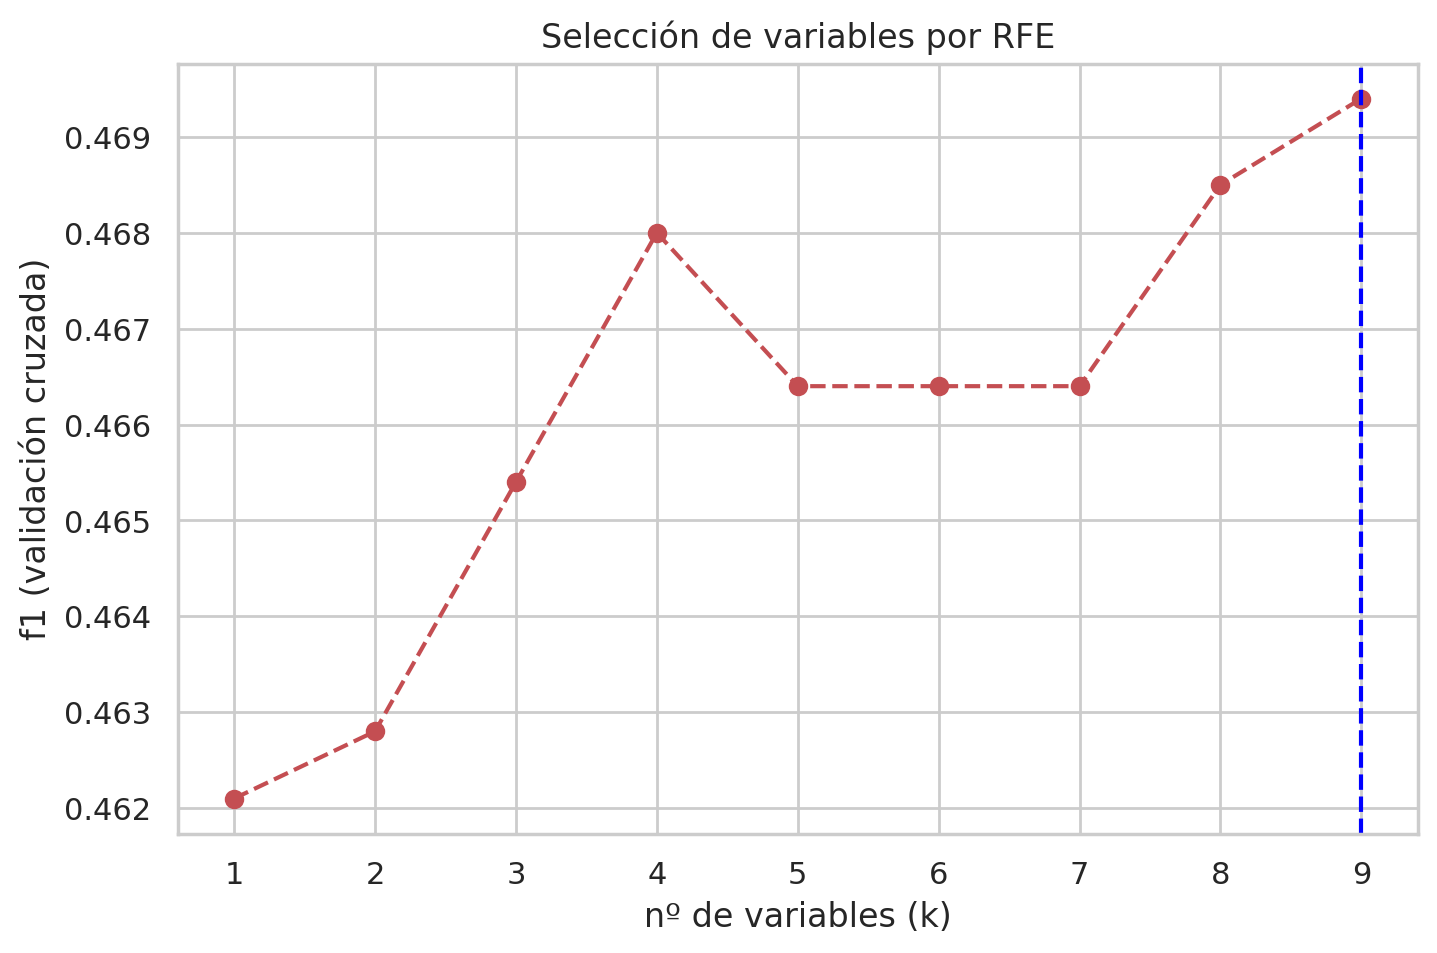

,k,accuracy,f1,recall,Nueva Variable
0,1,0.6099,0.4621,0.6099,Solids
1,2,0.6099,0.4628,0.6099,Hardness
2,3,0.6111,0.4654,0.6111,Sulfate
3,4,0.6122,0.4680,0.6122,Chloramines
4,5,0.6103,0.4664,0.6103,Organic_carbon
5,6,0.6103,0.4664,0.6103,Conductivity
6,7,0.6103,0.4664,0.6103,Trihalomethanes
7,8,0.6107,0.4685,0.6107,ph
8,9,0.6111,0.4694,0.6111,Turbidity


In [28]:
datos_pp, _ = preprocesar_datos(water, 'Potability')
X = datos_pp.drop('Potability', axis=1)
y = datos_pp['Potability']
scores_df, variables, k_best, score_best = select_variables(
    LogisticRegression(max_iter=5000), xtrain, ytrain, range(1, xtrain.shape[1]+1), 'f1', cv=5)

print(f"k óptimo: {k_best}  |  f1: {score_best:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(scores_df.k, scores_df.f1, 'o--', color='r')
plt.axvline(k_best, color='blue', ls='--')
plt.xlabel('nº de variables (k)')
plt.ylabel('f1 (validación cruzada)')
plt.title('Selección de variables por RFE')
plt.grid(True)
plt.show()
scores_df.round(4)

Como el resultado contieen demasiadas variables vamos a elegir las dos más relevantes y representar la solución del modelo con ellas.

Dos variables más relevantes: ['Hardness', 'Solids']


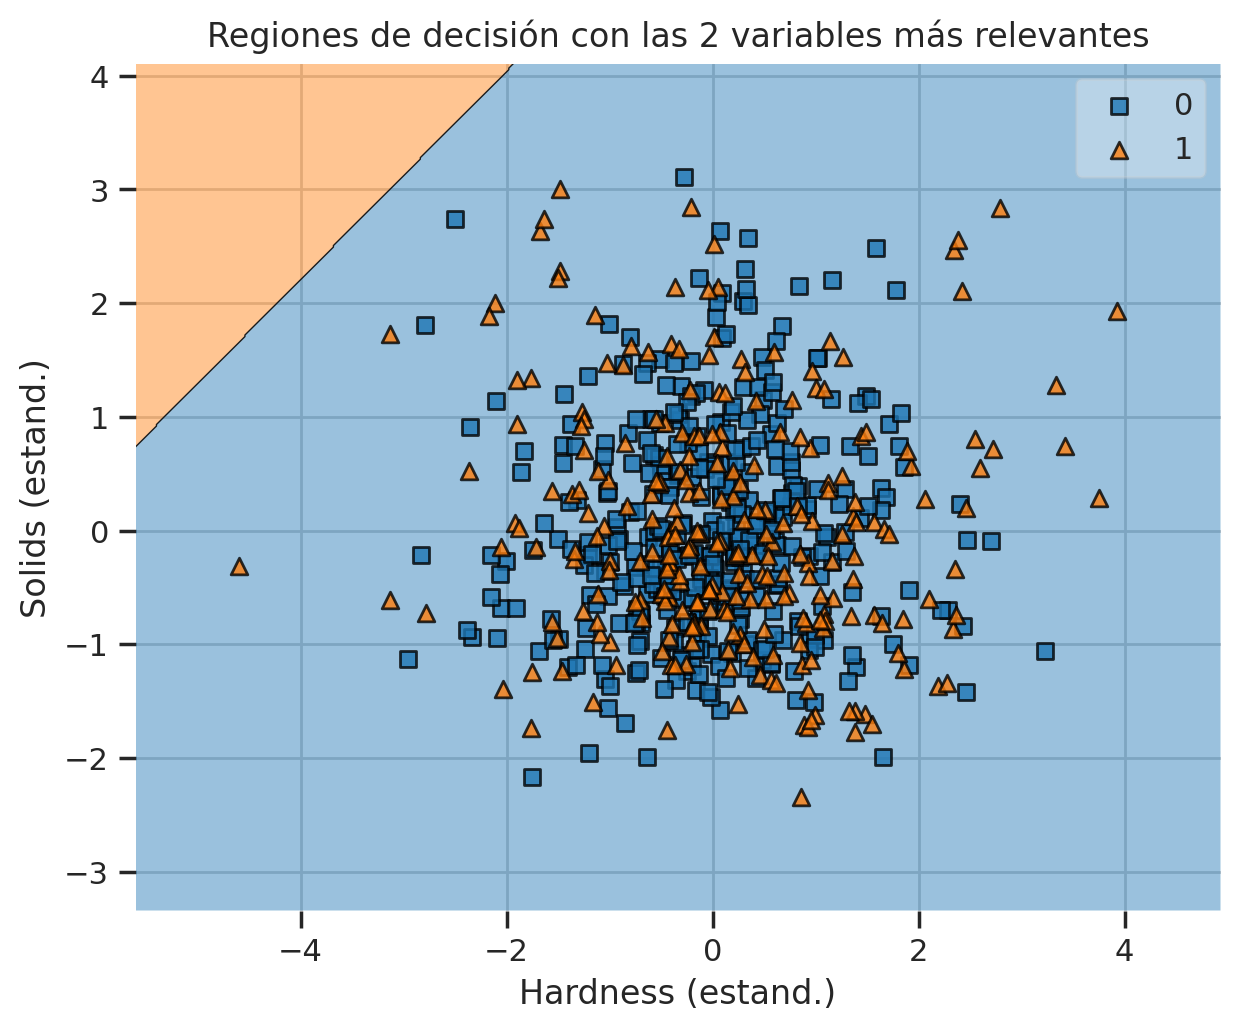

In [29]:
# Dos variables más relevantes (RFE) y regiones de decisión
sel2 = RFE(LDA(), n_features_to_select=2).fit(xtrain, ytrain)
top2 = xtrain.columns[sel2.support_].tolist()
print('Dos variables más relevantes:', top2)
modelo_2v = LDA().fit(xtrain[top2], ytrain)
fig, ax = plt.subplots(figsize=(7, 5.5))
plot_decision_regions(X=xtest[top2].values, y=ytest.astype(int).values, clf=modelo_2v, ax=ax)
ax.set_xlabel(top2[0] + ' (estand.)')
ax.set_ylabel(top2[1] + ' (estand.)')
ax.set_title('Regiones de decisión con las 2 variables más relevantes')
plt.show()

La curva de selección muestra que el rendimiento (ya de por sí bajo) **se estabiliza enseguida**: pocas variables bastan para alcanzar el techo de este problema. En el mapa de regiones con las dos variables más relevantes se aprecia visualmente por qué el LDA falla: las dos clases están **completamente entremezcladas**, no hay una recta (ni casi ninguna frontera) que las separe.



### <font color="steelblue">5.3.2. Equilibrado de clases: comparación de estrategias</font>

Como la clase **potable** está infrarrepresentada y el modelo base casi no la detecta, probamos tres formas de **equilibrar** y las comparamos con el modelo base. Conviene entender **qué hace cada una**:

* **Prioris iguales (`priors=[0.5, 0.5]`)** — es la "ponderación de clases" propia del LDA. Recuerda que el LDA clasifica maximizando $\pi_k f_k(x)$; con datos desbalanceados, la $\pi$ de la clase mayoritaria es alta y "empuja" todas las decisiones hacia ella. Al fijar **prioris iguales** le decimos al modelo que, *a priori*, ambas clases son igual de probables, eliminando esa ventaja. (El LDA **no** tiene parámetro `class_weight` como la regresión logística; este es su equivalente.)
* **SMOTE (*Synthetic Minority Over-sampling*)** — **sobremuestrea** la clase minoritaria creando ejemplos **sintéticos**: toma un punto minoritario, busca uno de sus vecinos de la misma clase e **interpola** un nuevo punto entre ambos. Así iguala los tamaños **sin** limitarse a duplicar filas (lo que reduce el sobreajuste a copias exactas). Se aplica **solo al entrenamiento**.
* **NearMiss** — hace lo contrario: **submuestrea** la clase mayoritaria, **conservando** los ejemplos mayoritarios **más cercanos** a la minoría (los más "informativos" para la frontera) y descartando el resto.

El siguiente código aplica cada estrategia (los remuestreos, solo sobre el *train*) y ajusta un LDA con cada conjunto resultante.

In [30]:
# (a) Prioris iguales: equivalente en LDA a "ponderar" las clases
modelo_priors = LDA(priors=[0.5, 0.5]).fit(xtrain, ytrain)

# (b) SMOTE: sobremuestreo sintético de la minoría (solo en entrenamiento)
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
modelo_smote = LDA().fit(xtr_sm, ytr_sm)
print('Tamaños tras SMOTE:', ytr_sm.value_counts().to_dict())

# (c) NearMiss: submuestreo de la mayoría (solo en entrenamiento)
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
modelo_nm = LDA().fit(xtr_nm, ytr_nm)
print('Tamaños tras NearMiss:', ytr_nm.value_counts().to_dict())

Tamaños tras SMOTE: {0: 1598, 1: 1598}
Tamaños tras NearMiss: {0: 1022, 1: 1022}


Comparamos las **matrices de confusión** de los cuatro modelos con la **misma función** `matriz_confusion` (mismo formato que el resto del cuaderno).

— Modelo BASE —


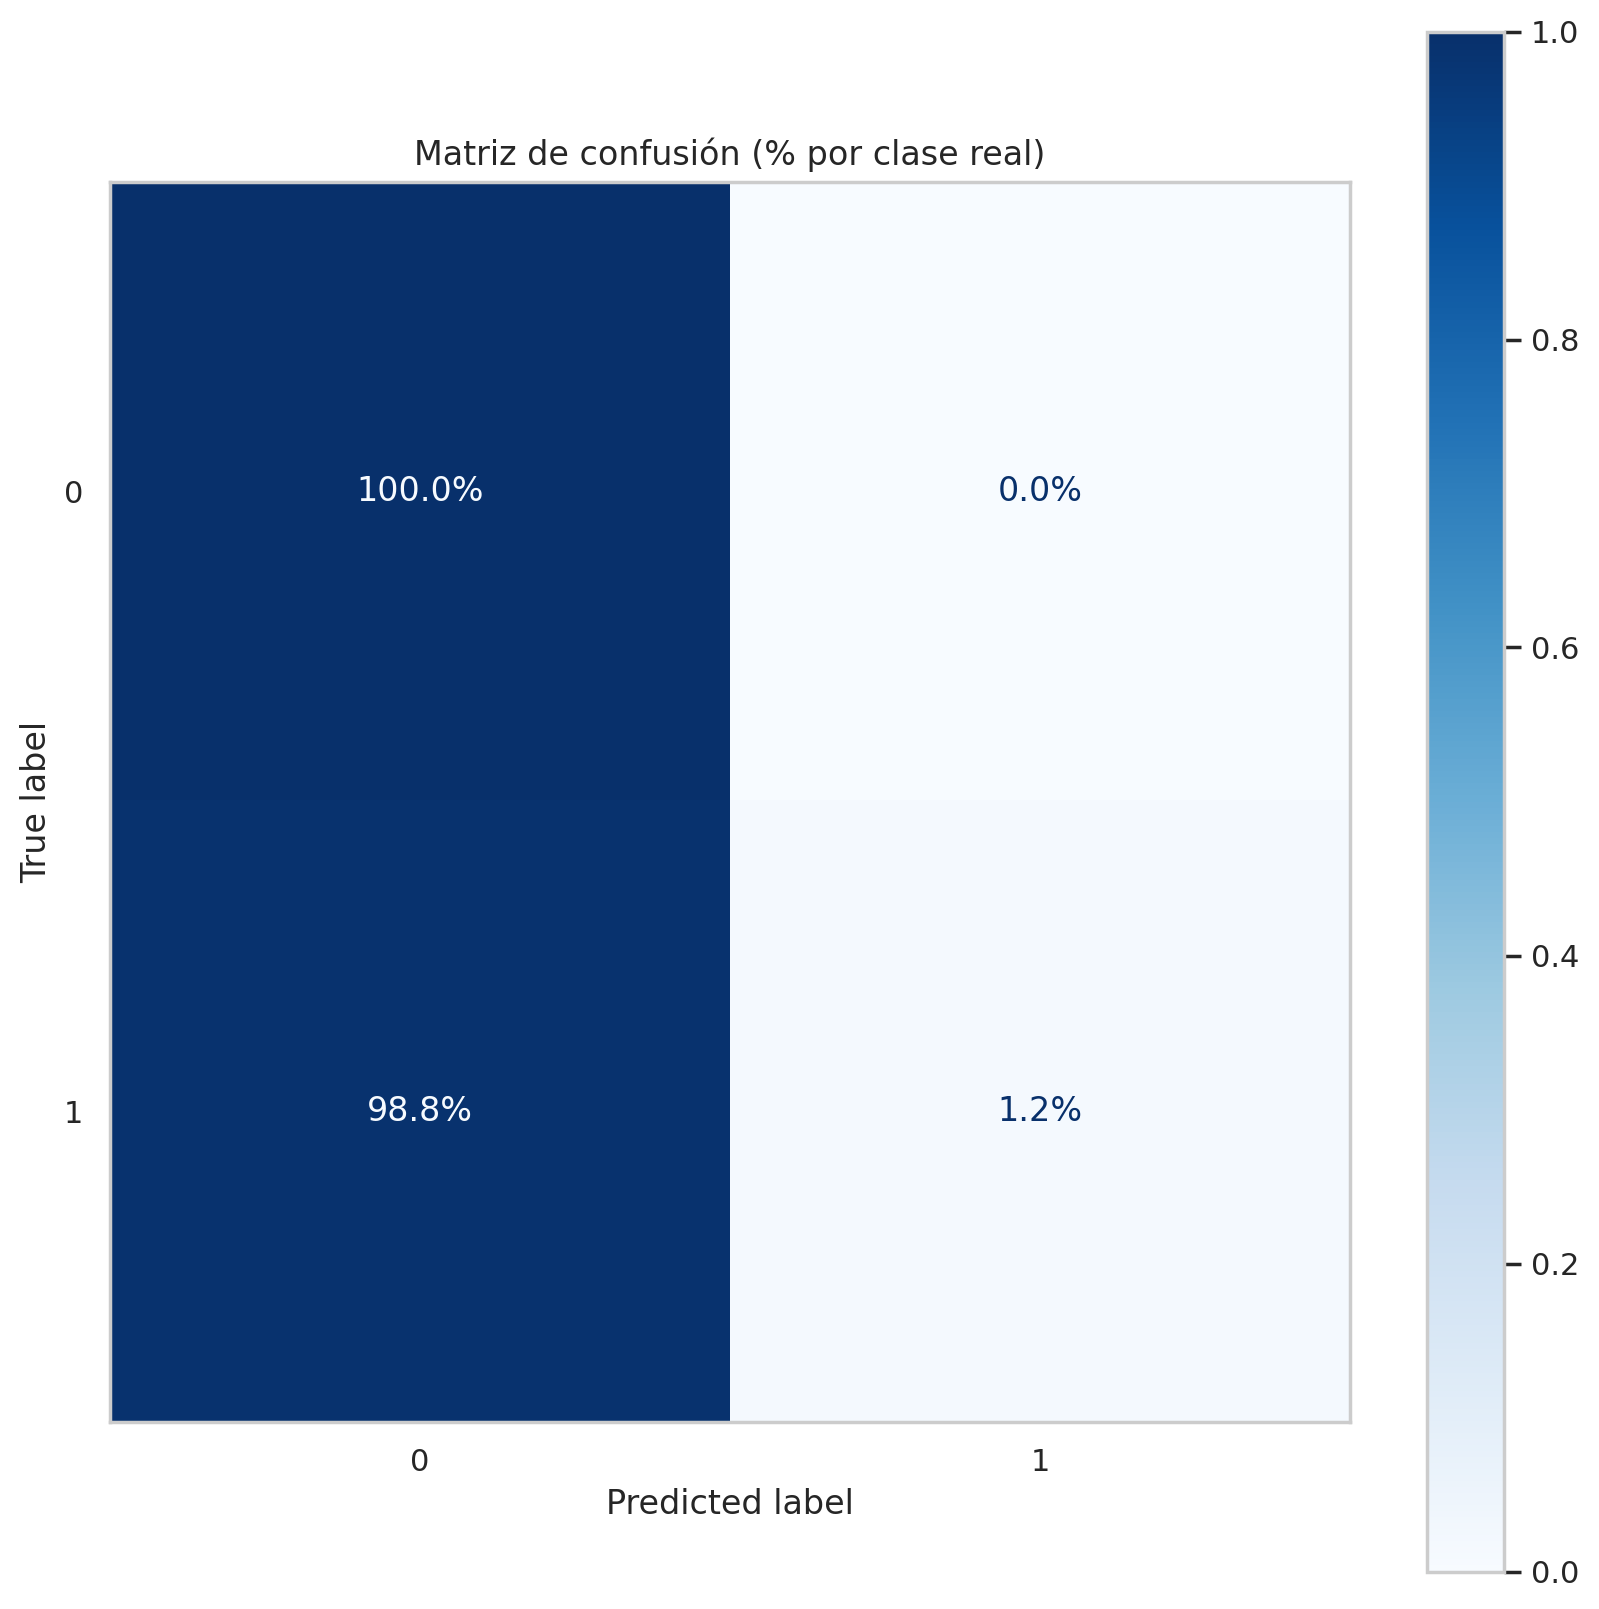

In [31]:
print('— Modelo BASE —'); matriz_confusion(modelo, xtest, ytest);

— Prioris iguales (ponderación) —


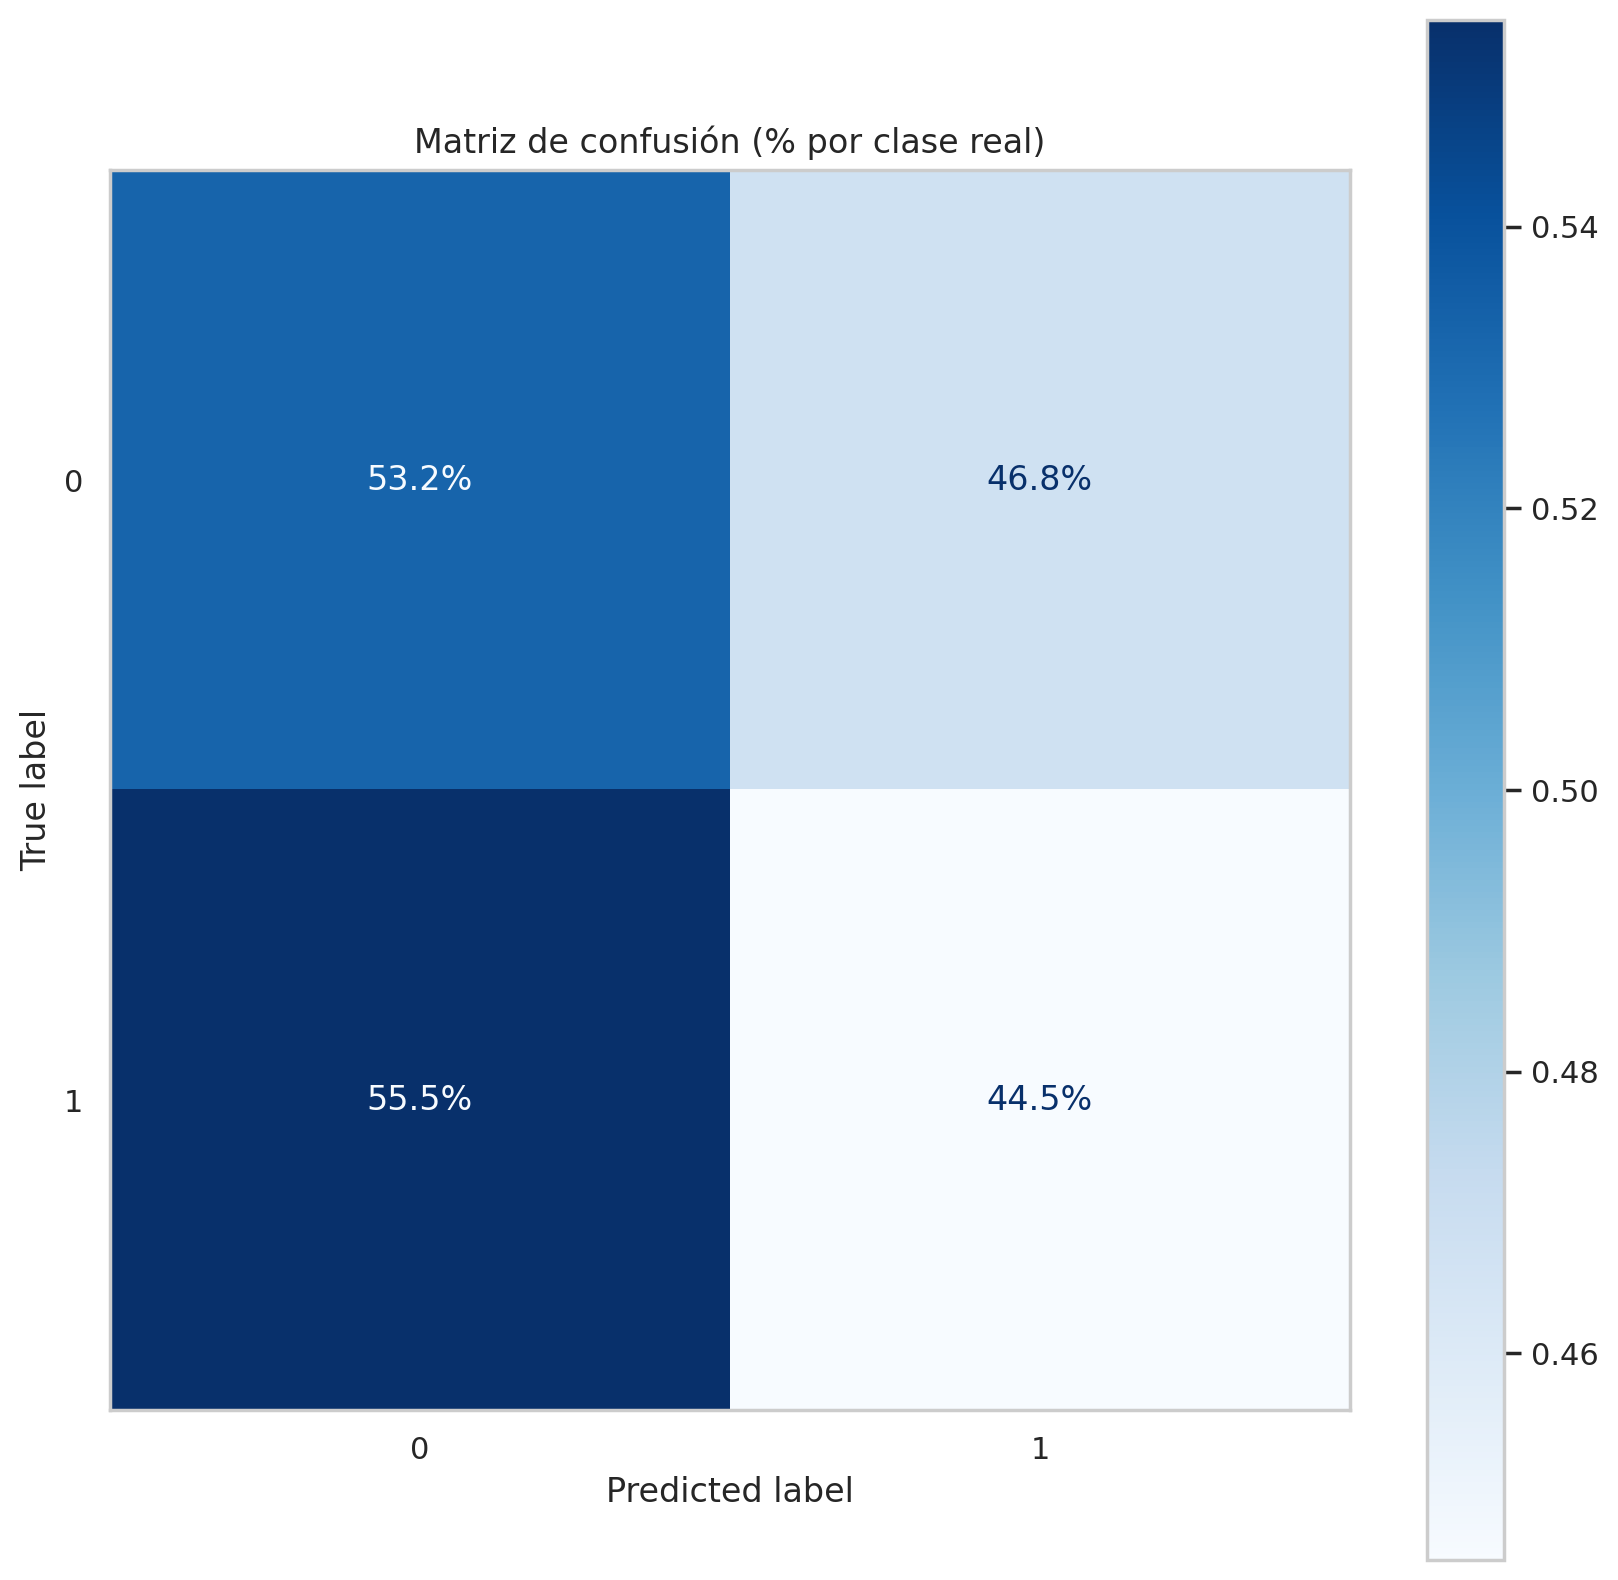

In [32]:
print('— Prioris iguales (ponderación) —'); matriz_confusion(modelo_priors, xtest, ytest);

— SMOTE —


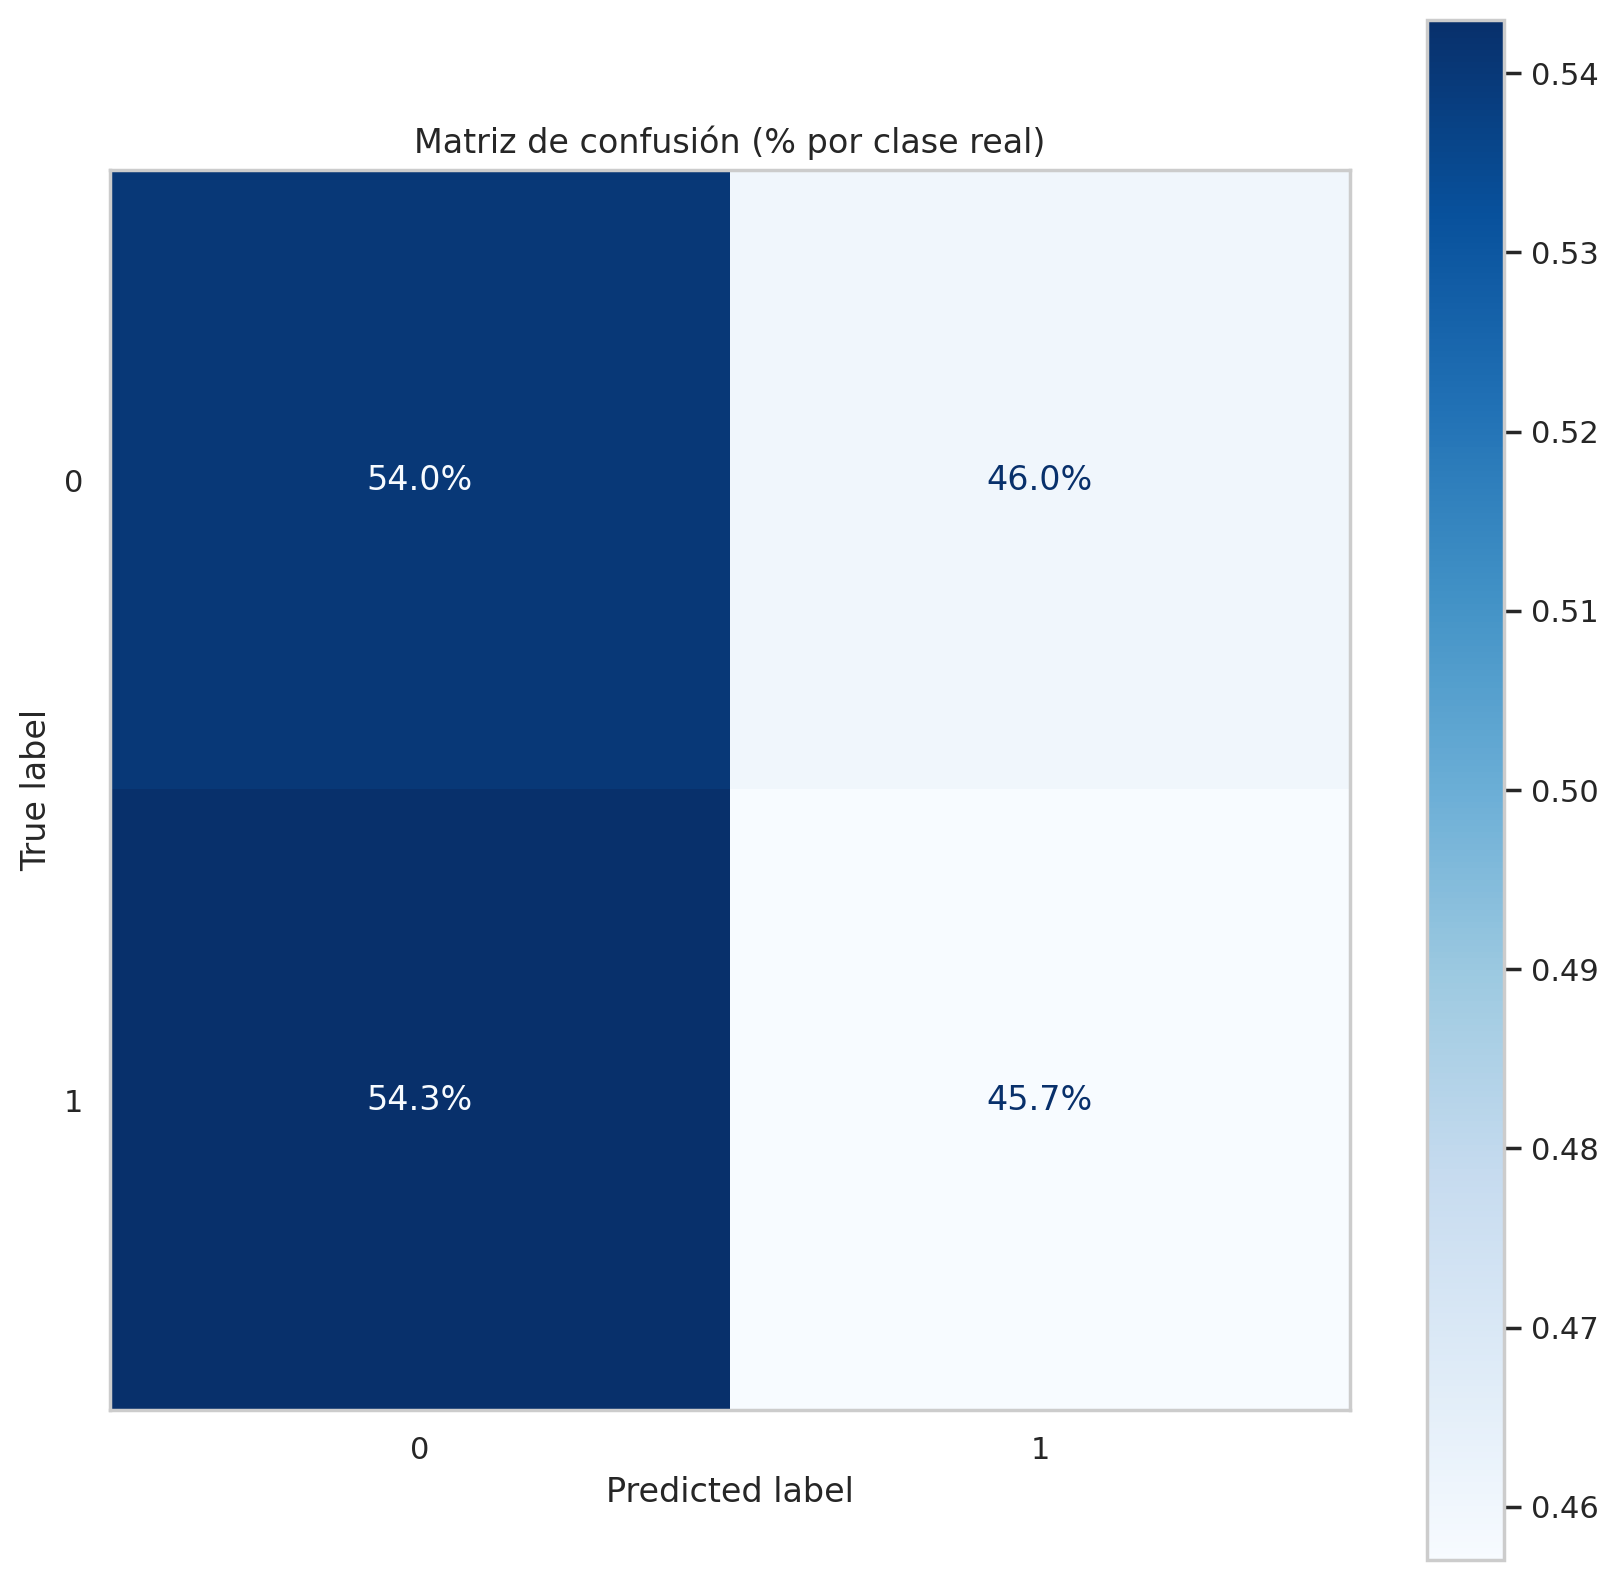

In [33]:
print('— SMOTE —'); matriz_confusion(modelo_smote, xtest, ytest);

— NearMiss —


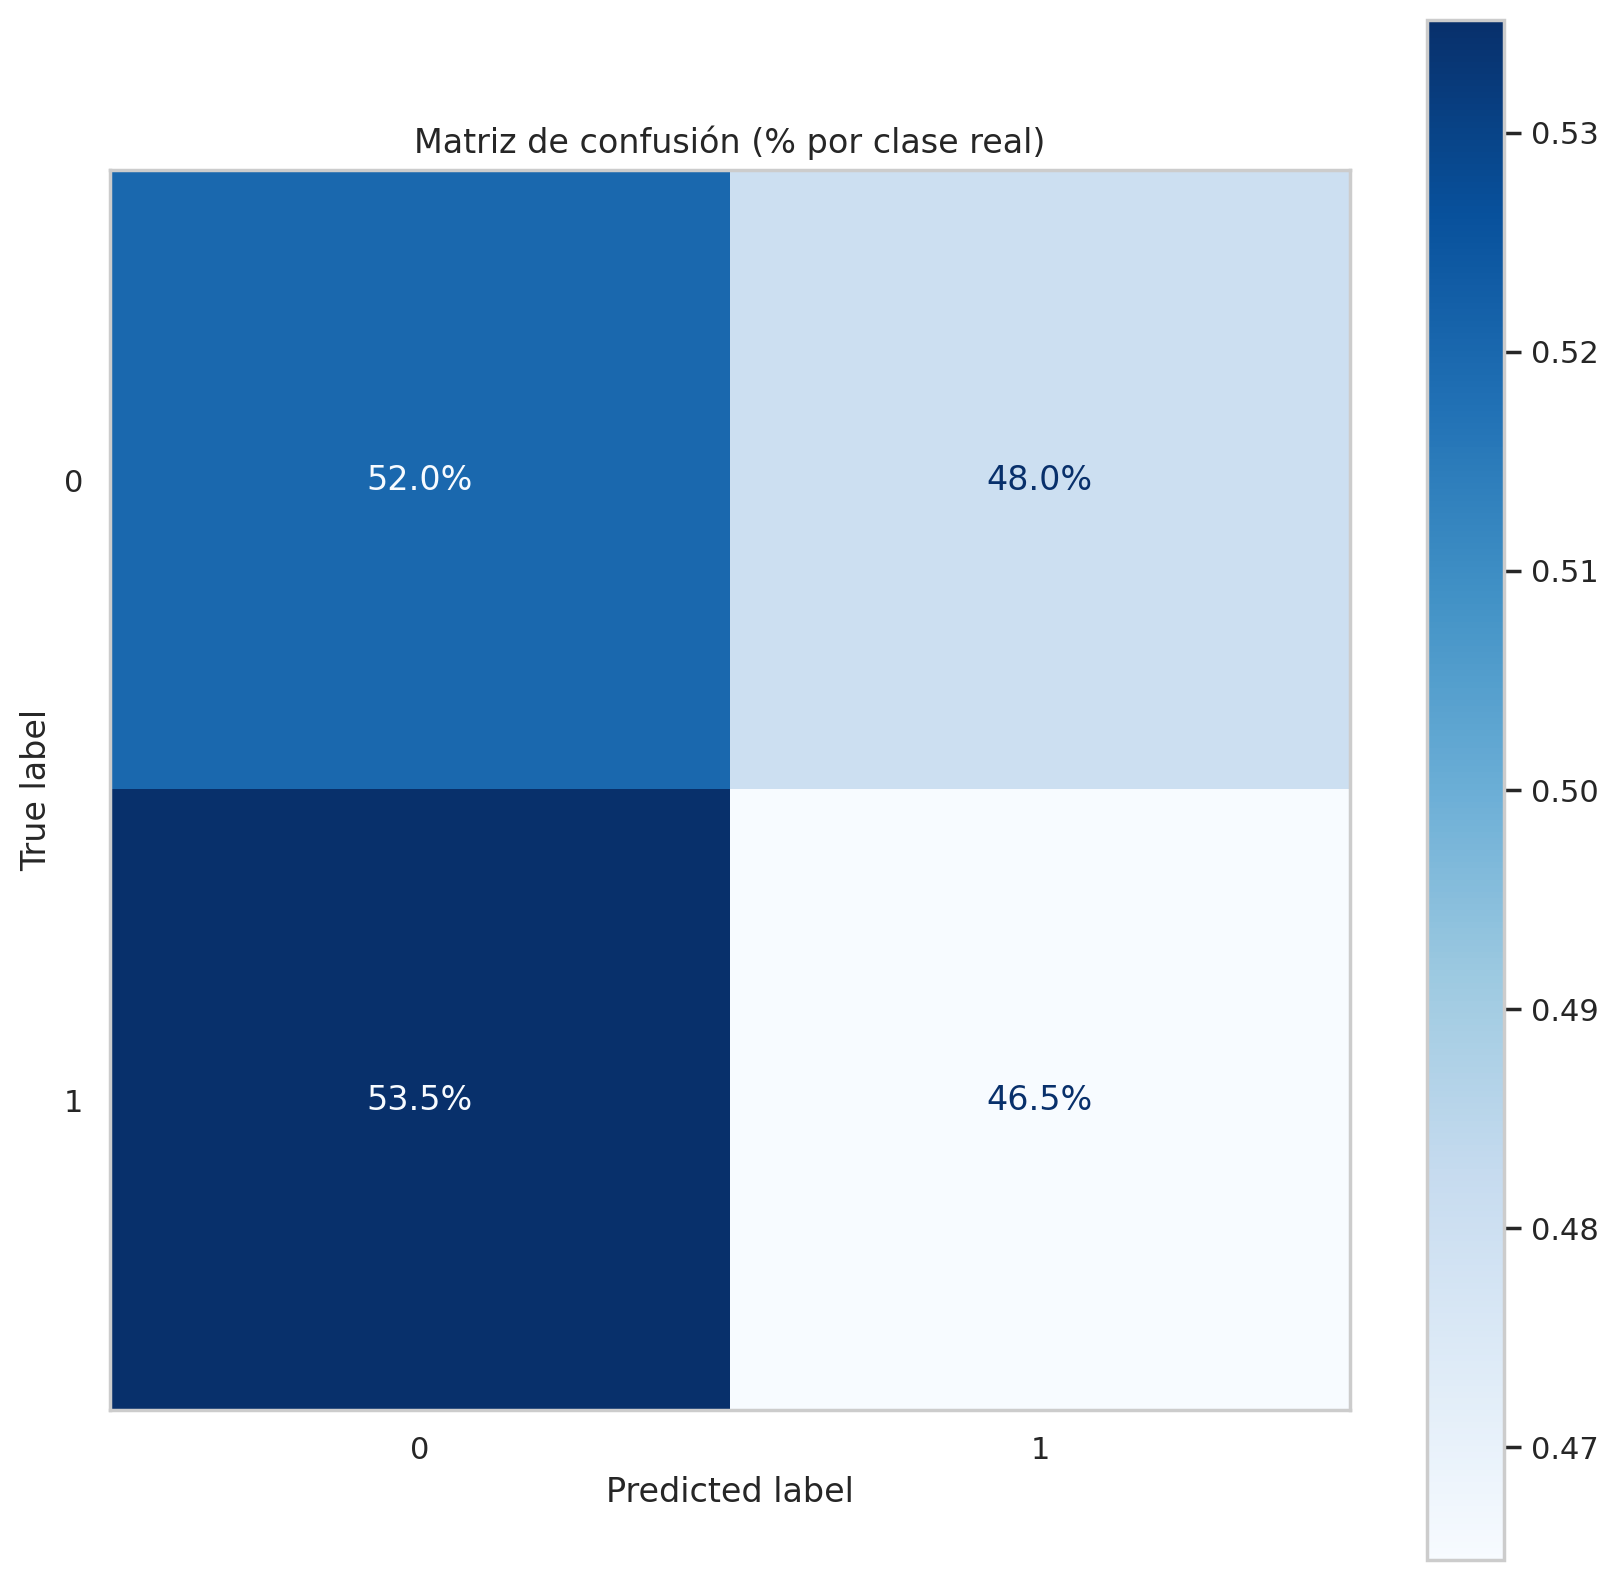

In [34]:
print('— NearMiss —'); matriz_confusion(modelo_nm, xtest, ytest);

In [35]:
# Resumen del recall de la clase minoritaria (potable = 1)
resumen = pd.DataFrame({
    'modelo': ['Base', 'Prioris iguales', 'SMOTE', 'NearMiss'],
    'recall_potable': [recall_score(ytest, m.predict(xtest), pos_label=1)
                       for m in [modelo, modelo_priors, modelo_smote, modelo_nm]]})
resumen.round(3)

,modelo,recall_potable
0,Base,0.012
1,Prioris iguales,0.445
2,SMOTE,0.457
3,NearMiss,0.465


El modelo **base** maximiza la exactitud global ignorando casi por completo la clase potable (*recall* ≈ 0.01: casi ningún acierto en la minoría). Las **tres estrategias de equilibrado** corrigen ese sesgo y elevan el *recall* de la clase potable a valores **en torno a 0.45**: el modelo pasa a **detectar** muchos más casos potables, a costa de más falsos positivos y de bajar la exactitud global. No "arreglan" el problema (el poder discriminante sigue siendo limitado), pero **cambian el objetivo**: de "acertar mucho en total" a "tratar ambas clases de forma equitativa", que es lo deseable cuando la clase rara es la importante. Entre ellas, las diferencias son pequeñas aquí; en general SMOTE suele preservar más información que NearMiss (que descarta datos), y las prioris iguales son la opción más simple y sin coste computacional.



## <font color="steelblue">5.4. Aplicación real: abalones (3 grupos)</font>

**El banco de datos.** Los *abalones* (orejas de mar) son **moluscos marinos**. Este conjunto, muy usado en aprendizaje automático, recoge **4.177 ejemplares** medidos físicamente, y el objetivo aquí es clasificar su **sexo** (`Sex`) en tres categorías: **M** (macho), **F** (hembra) e **I** (*infant*, ejemplar juvenil aún sin sexo diferenciado). Las predictoras son medidas morfométricas: **`Length`**, **`Diameter`**, **`Height`** (dimensiones de la concha), los pesos **`Whole weight`**, **`Shucked weight`** (carne), **`Viscera weight`** (vísceras) y **`Shell weight`** (concha), y **`Rings`** (anillos de la concha, que se relacionan con la **edad**).

El problema es **intrínsecamente difícil**: machos y hembras adultos tienen **morfología muy parecida**, así que separarlos por tamaño es casi imposible; lo más distinguible es el grupo **I** (juveniles, más pequeños). De hecho, este conjunto se usa más a menudo para **predecir la edad** (los anillos) que el sexo. Lo cargamos ya preprocesado.

Dimensiones: (4177, 9)


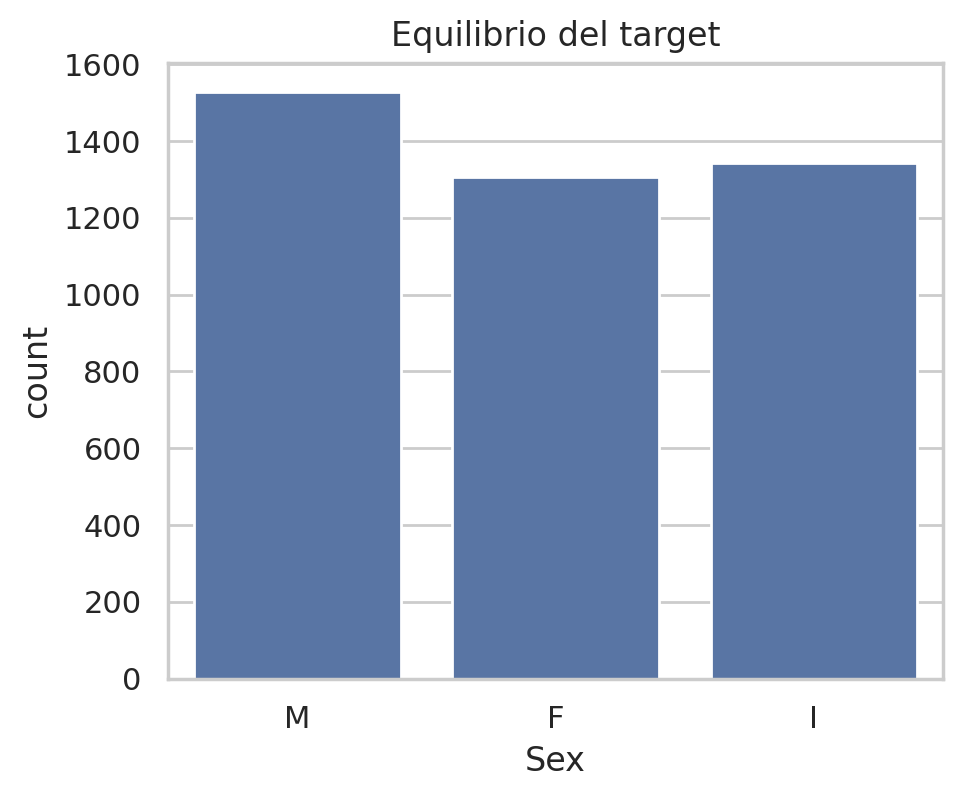

Proporciones: {'M': 0.366, 'I': 0.321, 'F': 0.313}


In [36]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0)
abalone['Sex'] = abalone['Sex'].astype('category')
print('Dimensiones:', abalone.shape)
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='Sex', data=abalone, order=['M','F','I'], ax=ax)
ax.set_title('Equilibrio del target')
plt.show()
print('Proporciones:', abalone['Sex'].value_counts(normalize=True).round(3).to_dict())

**Descriptivo.** Las tres clases están **bastante equilibradas** (≈37 % M, 31 % F, 32 % I). Hipótesis y preparación.

In [37]:
varpred = [c for c in abalone.columns if c != 'Sex']
for s in ['M','F','I']:
    gk = abalone[abalone['Sex'] == s]
    print(f'Normalidad grupo {s}:', pingouin.multivariate_normality(gk[varpred], alpha=.05))
print('\nM de Box:')
print(pingouin.box_m(abalone, dvs=varpred, group='Sex'))

Normalidad grupo M: HZResults(hz=np.float64(8.132356045031822), pval=np.float64(0.0), normal=False)
Normalidad grupo F: HZResults(hz=np.float64(8.203653495309975), pval=np.float64(0.0), normal=False)
Normalidad grupo I: HZResults(hz=np.float64(17.208381224421004), pval=np.float64(0.0), normal=False)

M de Box:
     Chi2    df  pval  equal_cov
box   NaN  72.0   NaN      False


In [38]:
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 42, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex')
stest,  _    = preprocesar_datos(stest_raw,  'Sex', prep)
xtrain, ytrain = strain.drop('Sex', axis=1), strain['Sex']
xtest,  ytest  = stest.drop('Sex', axis=1),  stest['Sex']
modelo = LDA().fit(xtrain, ytrain)
print('Varianza explicada:', np.round(modelo.explained_variance_ratio_, 3))

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
Varianza explicada: [0.988 0.012]


Visualizamos el **biplot canónico** (LD1-LD2) de la muestra de validación con las variables superpuestas (`scalings_`).

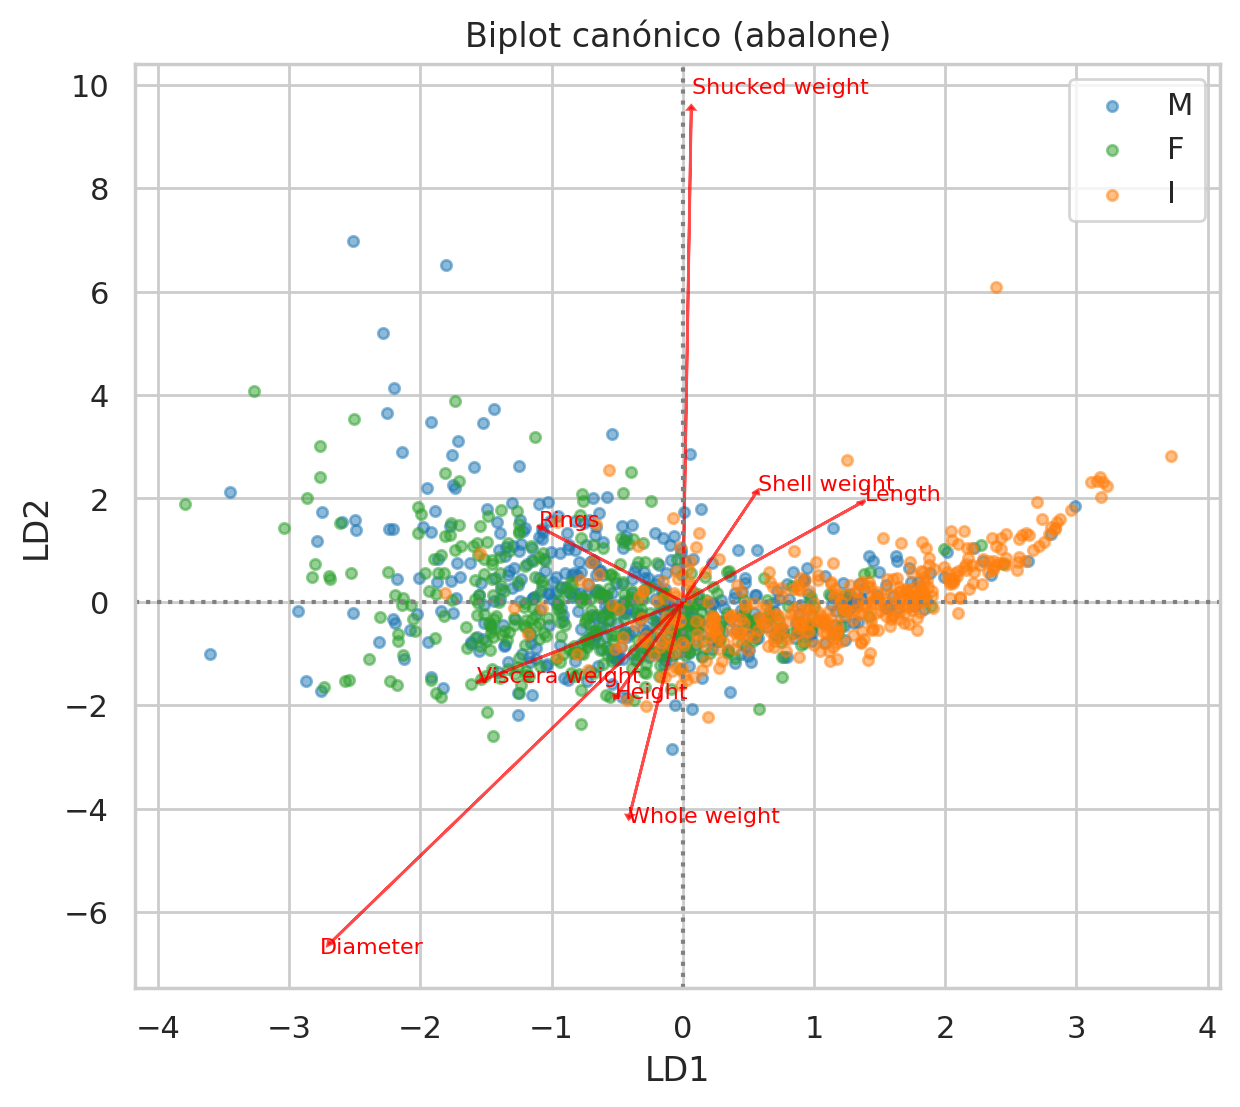

In [39]:
proy = modelo.transform(xtest)
sc = modelo.scalings_[:, :2]
fig, ax = plt.subplots(figsize=(7,6))
for s, col in zip(['M','F','I'], ['tab:blue','tab:green','tab:orange']):
    m = ytest.values == s
    ax.scatter(proy[m,0], proy[m,1], s=14, alpha=.5, color=col, label=s)
for i, lab in enumerate(xtrain.columns):
    ax.arrow(0,0, sc[i,0]*3, sc[i,1]*3, color='red', head_width=.05, alpha=.7); ax.annotate(lab, (sc[i,0]*3.1, sc[i,1]*3.1), color='red', fontsize=8)
ax.axhline(0, color='gray', ls=':')
ax.axvline(0, color='gray', ls=':')
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.legend()
ax.set_title('Biplot canónico (abalone)')
plt.show()

El grupo **I** se separa algo sobre **LD1**, pero **M** y **F** se **solapan fuertemente**. Evaluamos el modelo entrenado.

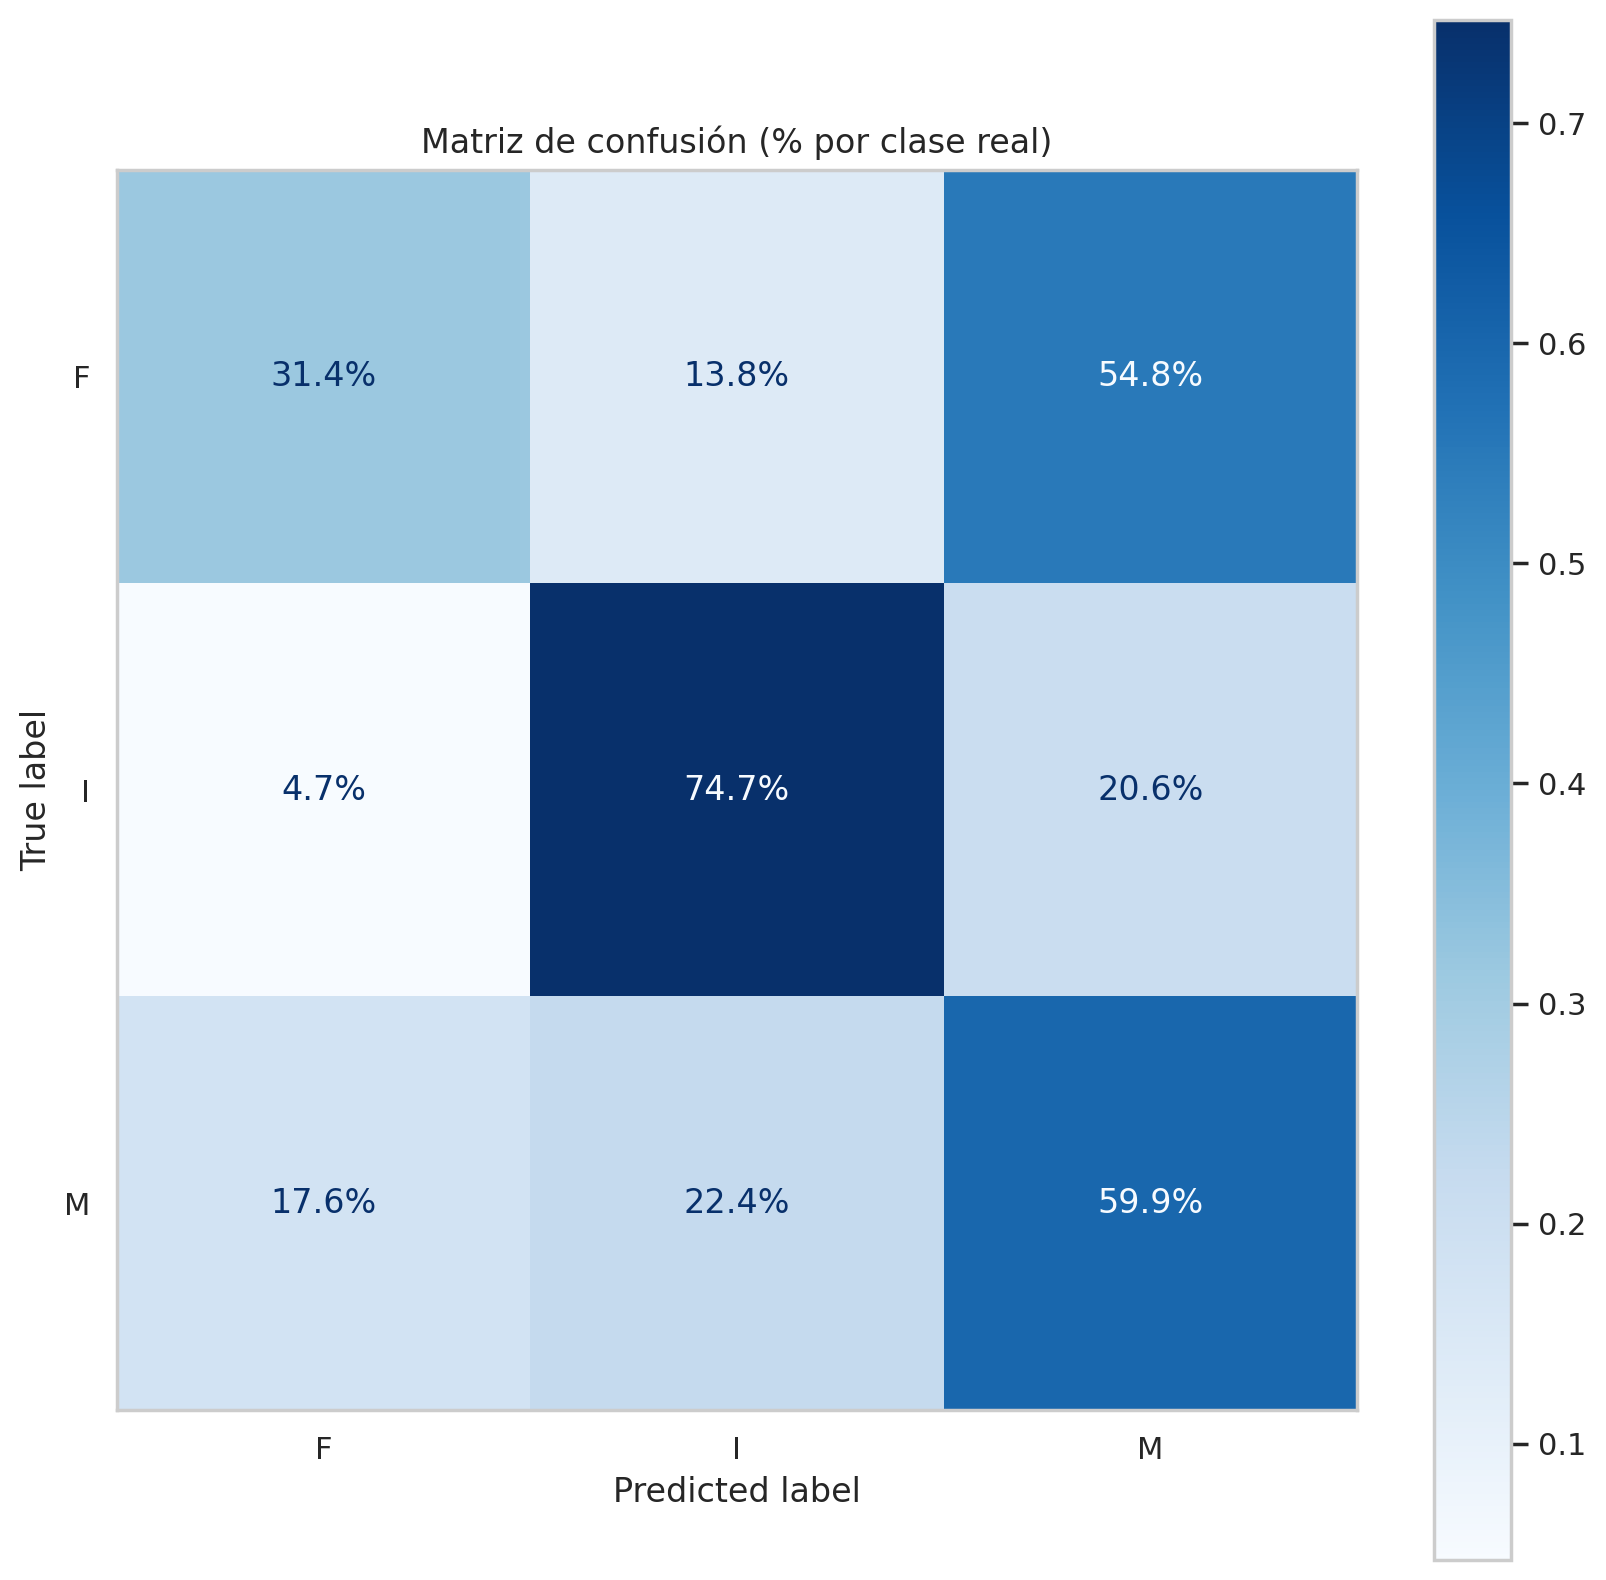

In [40]:
matriz_confusion(modelo, xtest, ytest);

In [41]:
val = validar_modelo(modelo, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.541 +/- 0.033


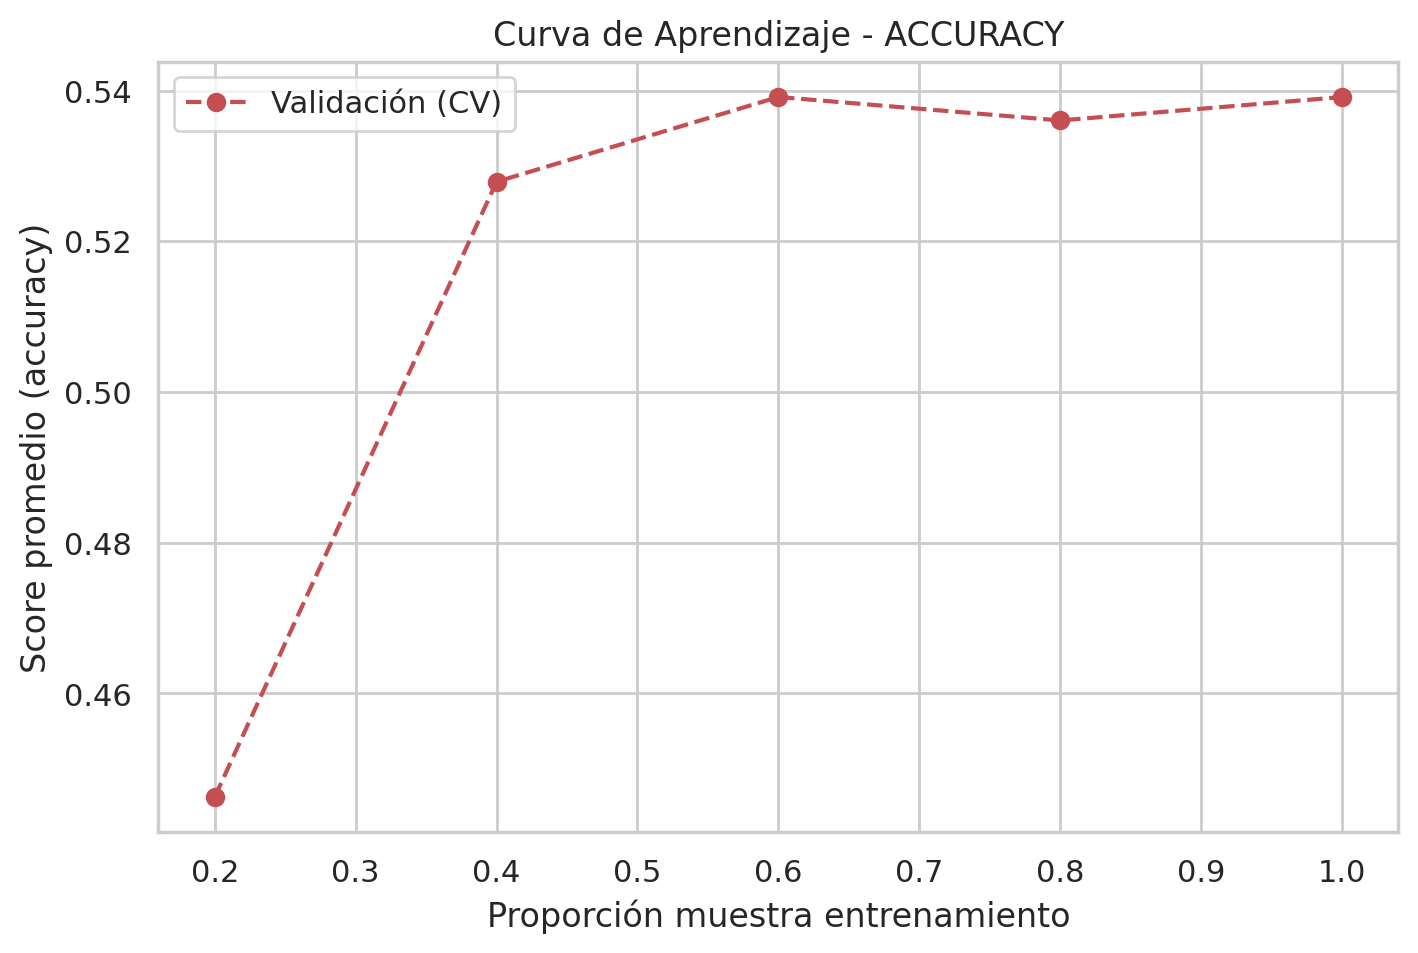

In [42]:
datos_pp, _ = preprocesar_datos(abalone, 'Sex')
X = datos_pp.drop('Sex', axis=1)
y = datos_pp['Sex']
curva_aprendizaje(modelo, X, y, 'accuracy', 10);

La matriz confirma el *biplot*: **I** se reconoce razonablemente pero **M/F** se confunden, lo que limita la exactitud a ~0.53–0.55. La validación es **estable**, así que es **dificultad del problema**, no azar.



### <font color="steelblue">5.4.1. Selección de variables y regiones de decisión</font>

Igual que con el agua, seleccionamos variables y dibujamos las regiones con las **2 más relevantes**.

Calculando el ranking global de variables (puede tardar un momento)...
Evaluando combinaciones optimizando por: F1...

k óptimo: 7  |  f1: 0.5365


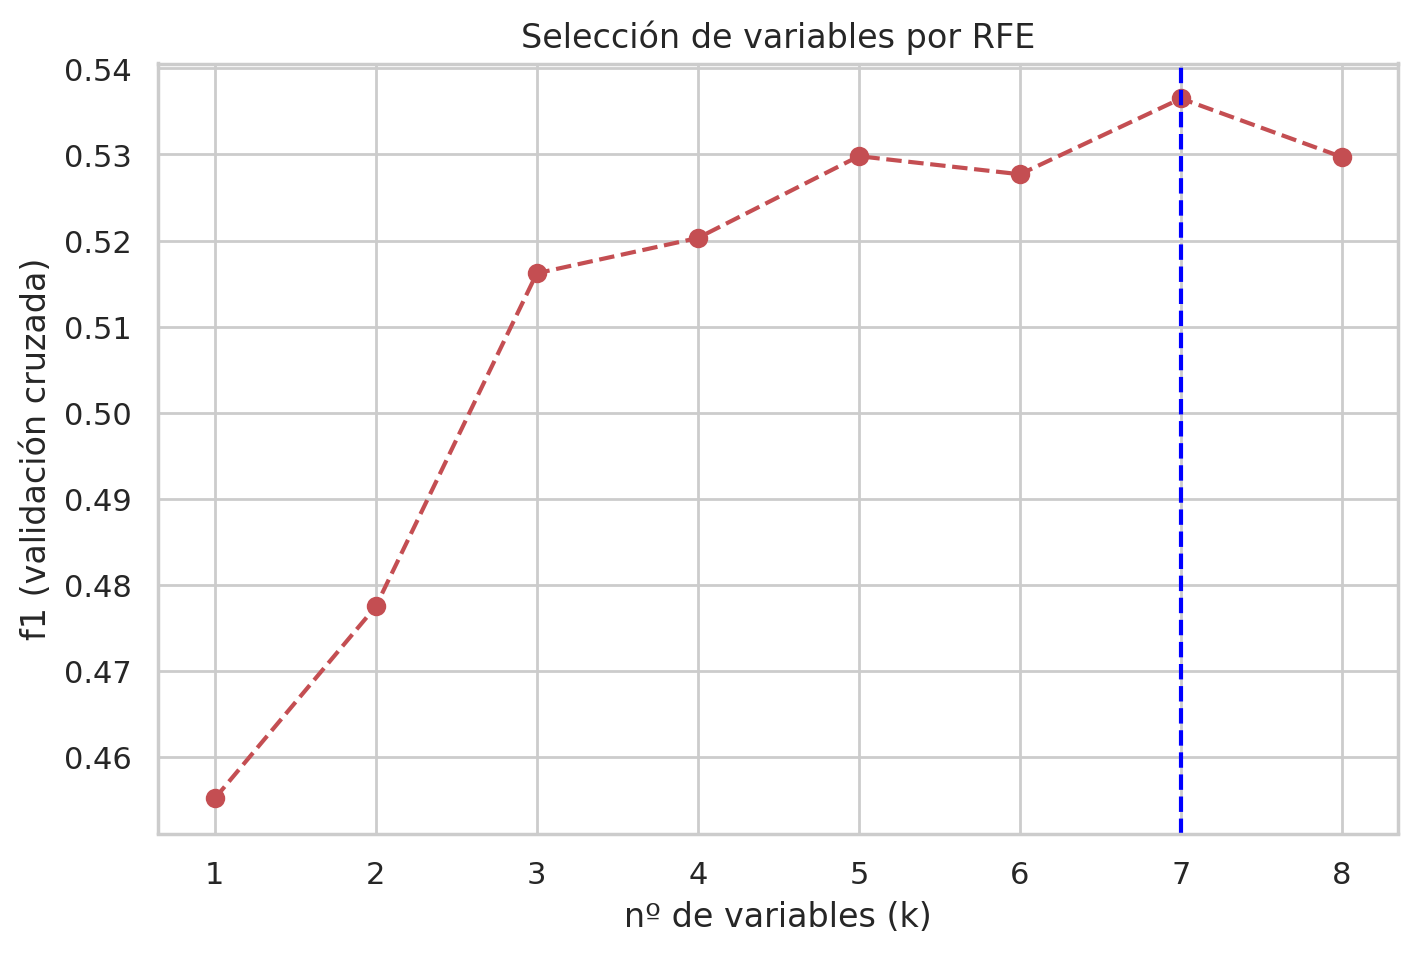

,k,accuracy,f1,recall,Nueva Variable
0,1,0.5306,0.4552,0.5306,Whole weight
1,2,0.5347,0.4775,0.5347,Viscera weight
2,3,0.5488,0.5162,0.5488,Length
3,4,0.5457,0.5203,0.5457,Diameter
4,5,0.5529,0.5298,0.5529,Rings
5,6,0.5470,0.5277,0.5470,Shucked weight
6,7,0.5539,0.5365,0.5539,Height
7,8,0.5470,0.5297,0.5470,Shell weight


In [43]:
scores_df, variables, k_best, score_best = select_variables(
    LogisticRegression(max_iter=5000), xtrain, ytrain, range(1, xtrain.shape[1]+1), 'f1', cv=5)

print(f"k óptimo: {k_best}  |  f1: {score_best:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(scores_df.k, scores_df.f1, 'o--', color='r')
plt.axvline(k_best, color='blue', ls='--')
plt.xlabel('nº de variables (k)')
plt.ylabel('f1 (validación cruzada)')
plt.title('Selección de variables por RFE')
plt.grid(True)
plt.show()
scores_df.round(4)

De nuevo el procso de selección no simplifica el conjunto de predictoras. Rerpesentamos de nuevo la solución para las dos predictoras más relevantes.

Dos variables más relevantes: ['Length', 'Diameter']
Códigos de clase: {0: 'F', 1: 'I', 2: 'M'}


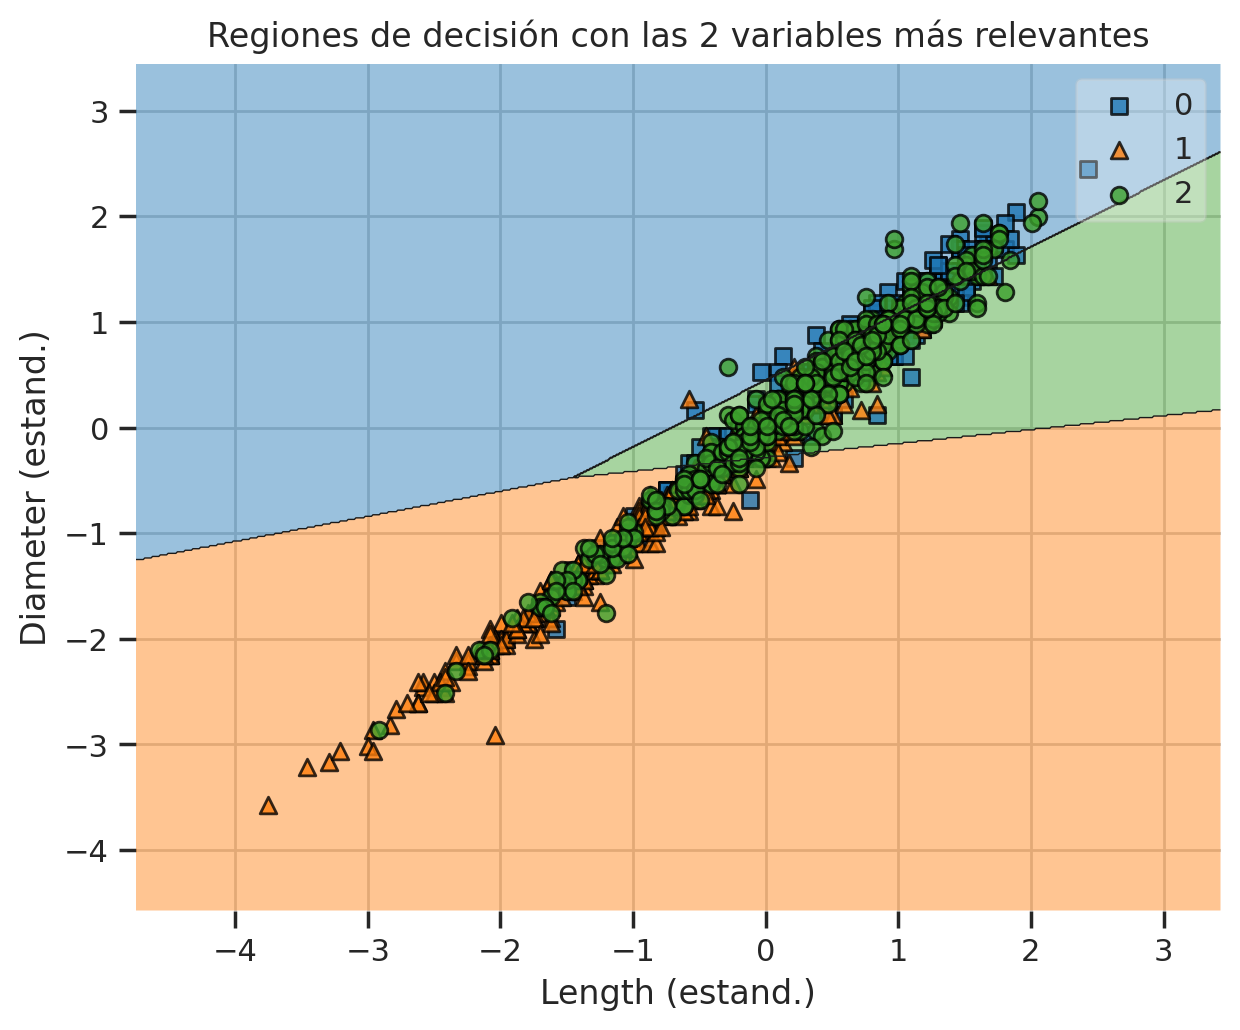

In [44]:
sel2 = RFE(LDA(), n_features_to_select=2).fit(xtrain, ytrain)
top2 = xtrain.columns[sel2.support_].tolist()
print('Dos variables más relevantes:', top2)
# mlxtend exige etiquetas enteras: codificamos el sexo (0,1,2) para el dibujo
codigos = dict(enumerate(ytrain.cat.categories))
print('Códigos de clase:', codigos)
modelo_2v = LDA().fit(xtrain[top2], ytrain.cat.codes)
fig, ax = plt.subplots(figsize=(7,5.5))
plot_decision_regions(X=xtest[top2].values, y=ytest.cat.codes.values, clf=modelo_2v, ax=ax)
ax.set_xlabel(top2[0] + ' (estand.)')
ax.set_ylabel(top2[1] + ' (estand.)')
ax.set_title('Regiones de decisión con las 2 variables más relevantes')
plt.show()

En el mapa de las dos variables más relevantes (clases codificadas como 0/1/2 según `codigos`) se ve cómo el LDA separa el grupo juvenil **I** del resto con una recta, pero **M y F quedan mezcladas** en la misma región: por eso la confusión entre esas dos clases es inevitable para un modelo lineal.

# <font color="steelblue">6. Optimización de hiperparámetros</font>

Los hiperparámetros del LDA son el **`solver`** y la **`shrinkage`** (contracción de la covarianza). Como `shrinkage` solo es compatible con `lsqr`/`eigen`, construimos la rejilla en consecuencia y la validamos con `GridSearchCV`. Lo hacemos en **los dos** conjuntos reales.




## <font color="steelblue">6.1. Optimización en *water potability*</font>

In [45]:
strain_raw, stest_raw = split_sample(water, 'Potability', 0.2, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'Potability'); stest, _ = preprocesar_datos(stest_raw, 'Potability', prep)
xtr_w, ytr_w = strain.drop('Potability', axis=1), strain['Potability']
xte_w, yte_w = stest.drop('Potability', axis=1),  stest['Potability']

pgrid = {'solver': ['lsqr', 'eigen'], 'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]}
gs_w = GridSearchCV(LDA(), pgrid, scoring='f1_weighted', cv=5)
gs_w.fit(xtr_w, ytr_w)
print('WATER  mejores hiperparámetros:', gs_w.best_params_, '| mejor f1_weighted CV:', round(gs_w.best_score_, 4))
print('f1_weighted test  —  base:', round(f1_score(yte_w, LDA().fit(xtr_w, ytr_w).predict(xte_w), average='weighted'), 4),
      '| optimizado:', round(f1_score(yte_w, gs_w.best_estimator_.predict(xte_w), average='weighted'), 4))

Estratificando por 'Potability'.
  Entrenamiento: 2620 muestras | Test: 656 muestras
WATER  mejores hiperparámetros: {'shrinkage': 0.5, 'solver': 'lsqr'} | mejor f1_weighted CV: 0.4704
f1_weighted test  —  base: 0.4723 | optimizado: 0.4689


## <font color="steelblue">6.2. Optimización en *abalone*</font>

In [46]:
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 42, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex')
stest, _ = preprocesar_datos(stest_raw, 'Sex', prep)
xtr_a, ytr_a = strain.drop('Sex', axis=1), strain['Sex']
xte_a, yte_a = stest.drop('Sex', axis=1),  stest['Sex']

gs_a = GridSearchCV(LDA(), pgrid, scoring='accuracy', cv=5)
gs_a.fit(xtr_a, ytr_a)
print('ABALONE  mejores hiperparámetros:', gs_a.best_params_, '| mejor accuracy CV:', round(gs_a.best_score_, 4))
print('accuracy test  —  base:', round(LDA().fit(xtr_a, ytr_a).score(xte_a, yte_a), 4),
      '| optimizado:', round(gs_a.best_estimator_.score(xte_a, yte_a), 4))

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
ABALONE  mejores hiperparámetros: {'shrinkage': None, 'solver': 'lsqr'} | mejor accuracy CV: 0.5436
accuracy test  —  base: 0.5574 | optimizado: 0.5574


En ambos casos `GridSearchCV` busca la mejor combinación de `solver`/`shrinkage`. Cuando hay **muchas muestras** (como aquí) la covarianza ya se estima bien y la contracción aporta **poco**; su utilidad crece cuando hay **pocas muestras o muchas variables**, situación en la que estabiliza la estimación y mejora la clasificación. La receta general es la de siempre: **modelo base → rejilla `solver`/`shrinkage` con `GridSearchCV` → comparar en test**.




# <font color="steelblue">7. Referencias</font>

* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 4). Springer.
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 4).
* Rencher, A. C. (2003). *Methods of Multivariate Analysis*. Wiley.
* Chawla et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. JAIR.
* scikit-learn — *Linear and Quadratic Discriminant Analysis*: https://scikit-learn.org/stable/modules/lda_qda.html
* imbalanced-learn: https://imbalanced-learn.org